# DSS Q2 v2 — Cervical Cancer Risk: Predictive Modelling

**Changes from v1:**
- Proper 20% stratified holdout — locked until Section 10
- ADASYN replaces SMOTE (fixes backwards smoking artifact)
- TabPFN replaces SVM (meta-learned transformer, ideal for n<1000)
- Per-model isotonic calibration before ensemble weighting
- Threshold tuned to flag ≤20% of patients (fixes 81% flag-rate bug)
- `Preg_x_Age` interaction feature added
- Full confidence score explainability: component waterfall + model contribution waterfall + natural language
- Patient population scatter (PCA) with current patient marked

**Install:**
```
pip install imbalanced-learn xgboost lightgbm shap tabpfn scikit-learn pandas numpy matplotlib seaborn joblib scipy
```

---
## 0. Imports & Config

In [1]:
import warnings, json, math
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from scipy.optimize import minimize
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve,
    brier_score_loss, fbeta_score,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN

try:
    import xgboost as xgb
    XGB_OK = True
except ImportError:
    XGB_OK = False
    from sklearn.ensemble import GradientBoostingClassifier
    print('XGBoost not found — using GradientBoostingClassifier')

try:
    import lightgbm as lgb
    LGB_OK = True
except ImportError:
    LGB_OK = False
    print('LightGBM not found — skipping')

try:
    from tabpfn import TabPFNClassifier, TabPFNLicenseError
    _test = TabPFNClassifier()
    TABPFN_OK = True
    print('TabPFN available ✓')
except Exception as e:
    TABPFN_OK = False
    print(f'TabPFN skipped: {type(e).__name__}')

import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

SEED      = 42
N_FOLDS   = 5
DATA_PATH = 'risk_factors_cervical_cancer.csv'
BUNDLE_PATH = 'cervical_model_bundle_v2.joblib'
PLOTS_DIR   = Path('model_plots_v2')
PLOTS_DIR.mkdir(exist_ok=True)

np.random.seed(SEED)
print('All imports OK.')

TabPFN skipped: ImportError
All imports OK.


---
## 1. Data Loading & Feature Preparation

In [2]:
df_raw   = pd.read_csv(DATA_PATH, na_values='?')
OUTCOMES = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']

missing_pct = df_raw.isnull().mean()
df = df_raw.drop(columns=missing_pct[missing_pct > 0.50].index.tolist())

feature_cols    = [c for c in df.columns if c not in OUTCOMES]
binary_cols     = [c for c in feature_cols if df[c].dropna().isin([0.0,1.0]).all()]
continuous_cols = [c for c in feature_cols if c not in binary_cols]

for col in continuous_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].median())
for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].mode()[0])

df['AnyAbnormal'] = df[OUTCOMES].max(axis=1).astype(int)
std_cols = [c for c in df.columns
            if c.startswith('STDs:') and c != 'STDs: Number of diagnosis']
df['STD_burden'] = df[std_cols].sum(axis=1)
df['AgeBucket']  = pd.cut(df['Age'], bins=[0,19,29,39,49,100],
                           labels=['<20','20-29','30-39','40-49','50+'])

# K-Means clusters (k=3)
CLUSTER_FEATURES = ['Age','Number of sexual partners','Num of pregnancies',
                    'Smokes (years)','Hormonal Contraceptives (years)',
                    'IUD (years)','STD_burden']
scaler_cluster = StandardScaler()
X_cluster      = scaler_cluster.fit_transform(df[CLUSTER_FEATURES])
km             = KMeans(n_clusters=3, random_state=SEED, n_init=10)
km.fit(X_cluster)
cluster_biopsy = {c: df[km.labels_==c]['Biopsy'].mean() for c in range(3)}
rank_map       = {c: r for r,c in enumerate(sorted(cluster_biopsy, key=cluster_biopsy.get))}
df['Cluster']  = pd.Series(km.labels_).map(rank_map).values

# ── Feature sets ──────────────────────────────────────────────────────────────
FEATURES_NODX = [
    'Age', 'Number of sexual partners', 'Num of pregnancies',
    'Smokes (years)', 'Hormonal Contraceptives (years)',
    'IUD (years)', 'STD_burden', 'Cluster',
]
FEATURES_FULL = FEATURES_NODX + ['Dx:Cancer', 'Dx:HPV']

# ── NEW: Interaction feature ───────────────────────────────────────────────────
df['Preg_x_Age'] = df['Num of pregnancies'] * df['Age']
FEATURES_NODX    = FEATURES_NODX + ['Preg_x_Age']
FEATURES_FULL    = FEATURES_FULL  + ['Preg_x_Age']

TARGET = 'Biopsy'
X_all  = df[FEATURES_NODX].copy()
y_all  = df[TARGET].values

print(f'Shape: {X_all.shape}  |  Features: {FEATURES_NODX}')
print(f'Biopsy positive rate: {y_all.mean():.1%}')
print(f'Cluster distribution:\n{df["Cluster"].value_counts().sort_index()}')

Shape: (858, 9)  |  Features: ['Age', 'Number of sexual partners', 'Num of pregnancies', 'Smokes (years)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STD_burden', 'Cluster', 'Preg_x_Age']
Biopsy positive rate: 6.4%
Cluster distribution:
Cluster
0    547
1    263
2     48
Name: count, dtype: int64


---
## 2. Stratified Holdout Split — Locked Until Section 10

**Rule:** `X_test` / `y_test` are not touched again until the final evaluation cell. All CV, OOF, weight optimisation, and threshold tuning use only `X_train` / `y_train`.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20, stratify=y_all, random_state=SEED
)

# ── Also split df for subgroup columns (AgeBucket, Cluster) ──────────────────
train_idx = X_train.index
test_idx  = X_test.index
df_train  = df.loc[train_idx].copy()
df_test   = df.loc[test_idx].copy()

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.1%}')
print(f'Test  positive rate: {y_test.mean():.1%}')
print('\n⚠  X_test is now locked — do not use until Section 10.')

Train: (686, 9)  |  Test: (172, 9)
Train positive rate: 6.4%
Test  positive rate: 6.4%

⚠  X_test is now locked — do not use until Section 10.


---
## 3. Model Definitions

| # | Model | Resampling | Notes |
|---|-------|-----------|-------|
| 1 | Logistic Regression | ADASYN | Linear baseline |
| 2 | Random Forest | ADASYN | Tree ensemble |
| 3 | XGBoost / GBM | ADASYN | Gradient boosting |
| 4 | LightGBM | ADASYN | Fast boosting |
| 5 | TabPFN | None | Meta-learned transformer, handles imbalance natively |

**ADASYN** generates synthetic minority samples in harder-to-classify regions, unlike SMOTE which interpolates uniformly — less likely to invert feature relationships.  
**TabPFN** uses a prior trained on millions of synthetic datasets; no hyperparameter tuning, no scaling needed.

In [4]:
def make_adasyn_pipeline(classifier):
    return ImbPipeline([
        ('scaler',   StandardScaler()),
        ('resample', ADASYN(random_state=SEED, n_neighbors=5)),
        ('clf',      classifier),
    ])


# 1 — Logistic Regression
lr = make_adasyn_pipeline(
    LogisticRegression(C=0.5, solver='lbfgs', max_iter=2000,
                       class_weight='balanced', random_state=SEED)
)

# 2 — Random Forest
rf = make_adasyn_pipeline(
    RandomForestClassifier(n_estimators=500, max_depth=None,
                           min_samples_leaf=2, max_features='sqrt',
                           class_weight='balanced', n_jobs=-1, random_state=SEED)
)

# 3 — XGBoost
pos_weight = int((y_train==0).sum() / (y_train==1).sum())
if XGB_OK:
    xgb_clf = make_adasyn_pipeline(
        xgb.XGBClassifier(
            n_estimators=400, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=pos_weight,
            eval_metric='logloss', use_label_encoder=False,
            tree_method='hist', random_state=SEED, verbosity=0,
        )
    )
else:
    xgb_clf = make_adasyn_pipeline(
        GradientBoostingClassifier(n_estimators=400, max_depth=5,
                                   learning_rate=0.05, subsample=0.8,
                                   random_state=SEED)
    )

# 4 — LightGBM
if LGB_OK:
    lgb_clf = make_adasyn_pipeline(
        lgb.LGBMClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           class_weight='balanced', random_state=SEED, verbose=-1)
    )

# 5 — TabPFN (no pipeline needed — handles scaling + imbalance internally)
if TABPFN_OK:
    try:
        # TabPFN v2+ API
        tabpfn_clf = TabPFNClassifier(n_estimators=32, device='cpu')
    except TypeError:
        try:
            # TabPFN v1 API
            tabpfn_clf = TabPFNClassifier(N_ensemble_configurations=32, device='cpu')
        except TypeError:
            # Minimal fallback — no kwargs
            tabpfn_clf = TabPFNClassifier()
    print(f'TabPFN initialised: {tabpfn_clf}')

# ── Registry ──────────────────────────────────────────────────────────────────
MODELS = {'LR': lr, 'RF': rf, 'XGB': xgb_clf}
if LGB_OK:    MODELS['LGB']    = lgb_clf
if TABPFN_OK: MODELS['TabPFN'] = tabpfn_clf

print(f'Models registered: {list(MODELS.keys())}')
print(f'TabPFN included: {TABPFN_OK}')
print(f'ADASYN pipeline for tree/linear models: SMOTE replaced ✓')

Models registered: ['LR', 'RF', 'XGB', 'LGB']
TabPFN included: False
ADASYN pipeline for tree/linear models: SMOTE replaced ✓


---
## 4. Cross-Validated Training — Train Set Only

In [5]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_proba = {}
cv_scores = {}

for name, pipe in MODELS.items():
    print(f'\n── {name} ───────────────────────────────────────────────────')

    if name == 'TabPFN':
        # TabPFN has its own fit/predict — manual OOF
        oof_p = np.zeros(len(X_train))
        for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
            Xf_tr = X_train.iloc[tr_idx].values
            yf_tr = y_train[tr_idx]
            Xf_va = X_train.iloc[va_idx].values
            pipe.fit(Xf_tr, yf_tr)
            oof_p[va_idx] = pipe.predict_proba(Xf_va)[:, 1]
            print(f'  fold {fold}/5 done')
    else:
        oof_p = cross_val_predict(
            pipe, X_train, y_train, cv=cv, method='predict_proba'
        )[:, 1]

    oof_proba[name] = oof_p
    pred_05 = (oof_p >= 0.5).astype(int)
    cv_scores[name] = {
        'ROC-AUC':   round(roc_auc_score(y_train, oof_p), 4),
        'PR-AUC':    round(average_precision_score(y_train, oof_p), 4),
        'F1':        round(f1_score(y_train, pred_05), 4),
        'Recall':    round((pred_05[y_train==1]==1).mean(), 4),
        'Precision': round((pred_05[pred_05==1]==y_train[pred_05==1]).mean(), 4)
                     if pred_05.sum()>0 else 0,
        'Brier':     round(brier_score_loss(y_train, oof_p), 4),
    }
    print(pd.Series(cv_scores[name]).to_string())

# Fit final models on full train set
print('\n── Fitting final models on full train set ──────────────────────────────')
fitted_models = {}
for name, pipe in MODELS.items():
    if name == 'TabPFN':
        pipe.fit(X_train.values, y_train)
    else:
        pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    print(f'  {name} ✓')


── LR ───────────────────────────────────────────────────
ROC-AUC      0.5649
PR-AUC       0.0827
F1           0.1487
Recall       0.4545
Precision    0.0889
Brier        0.2371

── RF ───────────────────────────────────────────────────
ROC-AUC      0.6044
PR-AUC       0.0956
F1           0.0870
Recall       0.0682
Precision    0.1200
Brier        0.0854

── XGB ───────────────────────────────────────────────────
ROC-AUC      0.5754
PR-AUC       0.1029
F1           0.1296
Recall       0.1591
Precision    0.1094
Brier        0.1093

── LGB ───────────────────────────────────────────────────
ROC-AUC      0.5640
PR-AUC       0.1087
F1           0.1290
Recall       0.0909
Precision    0.2222
Brier        0.0766

── Fitting final models on full train set ──────────────────────────────
  LR ✓
  RF ✓
  XGB ✓
  LGB ✓


---
## 5. Per-Model Isotonic Calibration

Calibration ensures probabilities are meaningful before they're averaged into the ensemble. Without this, SVM-style and tree models output probabilities that cluster near 0 or 1, distorting the weighted average.

  LR: isotonic calibration applied ✓
  RF: isotonic calibration applied ✓
  XGB: isotonic calibration applied ✓
  LGB: isotonic calibration applied ✓


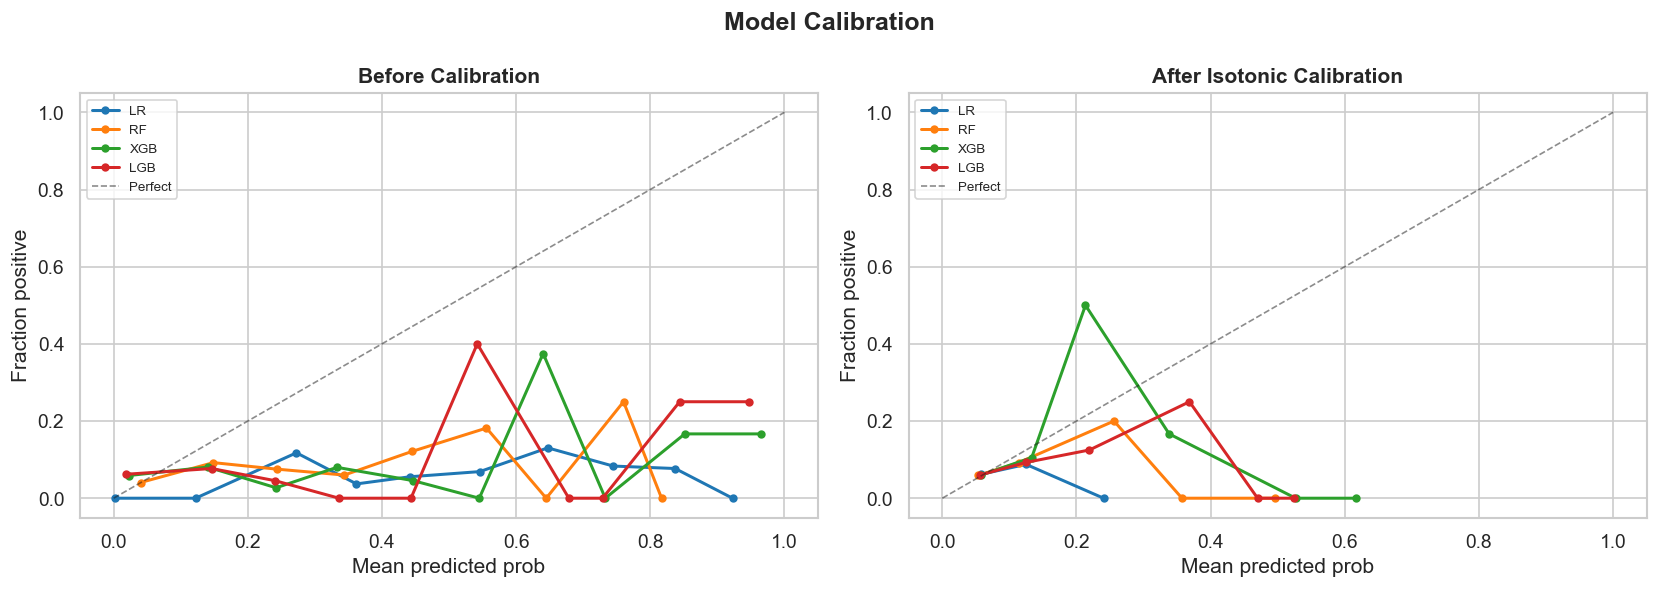

In [6]:
# Calibrate each model using 3-fold CV on the train set
calibrated_models = {}

for name, pipe in fitted_models.items():
    if name == 'TabPFN':
        # TabPFN already outputs well-calibrated posteriors — skip
        calibrated_models[name] = pipe
        print(f'  {name}: skipped (natively calibrated)')
    else:
        cal = CalibratedClassifierCV(pipe, cv=3, method='isotonic')
        cal.fit(X_train, y_train)
        calibrated_models[name] = cal
        print(f'  {name}: isotonic calibration applied ✓')

# Updated OOF probabilities from calibrated models
oof_proba_cal = {}
for name, cal_model in calibrated_models.items():
    if name == 'TabPFN':
        oof_proba_cal[name] = oof_proba[name]  # already used during CV
    else:
        oof_proba_cal[name] = cross_val_predict(
            calibrated_models[name], X_train, y_train,
            cv=cv, method='predict_proba'
        )[:, 1]

# Calibration curves
model_names = list(calibrated_models.keys())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, name in enumerate(model_names):
    for ax, p_before, p_after, linestyle in [
        (axes[0], oof_proba[name],     None, '-'),
        (axes[1], oof_proba_cal[name], None, '-'),
    ]:
        p = p_before if ax == axes[0] else oof_proba_cal[name]
        try:
            frac, mean = calibration_curve(y_train, p, n_bins=10, strategy='uniform')
            ax.plot(mean, frac, 'o-', color=colors[i], lw=1.8,
                    markersize=4, label=name)
        except Exception:
            pass

for ax, title in [
    (axes[0], 'Before Calibration'),
    (axes[1], 'After Isotonic Calibration'),
]:
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Perfect')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean predicted prob'); ax.set_ylabel('Fraction positive')
    ax.legend(fontsize=8)

plt.suptitle('Model Calibration', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'calibration.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 6. ROC / PR Curves & Confusion Matrices

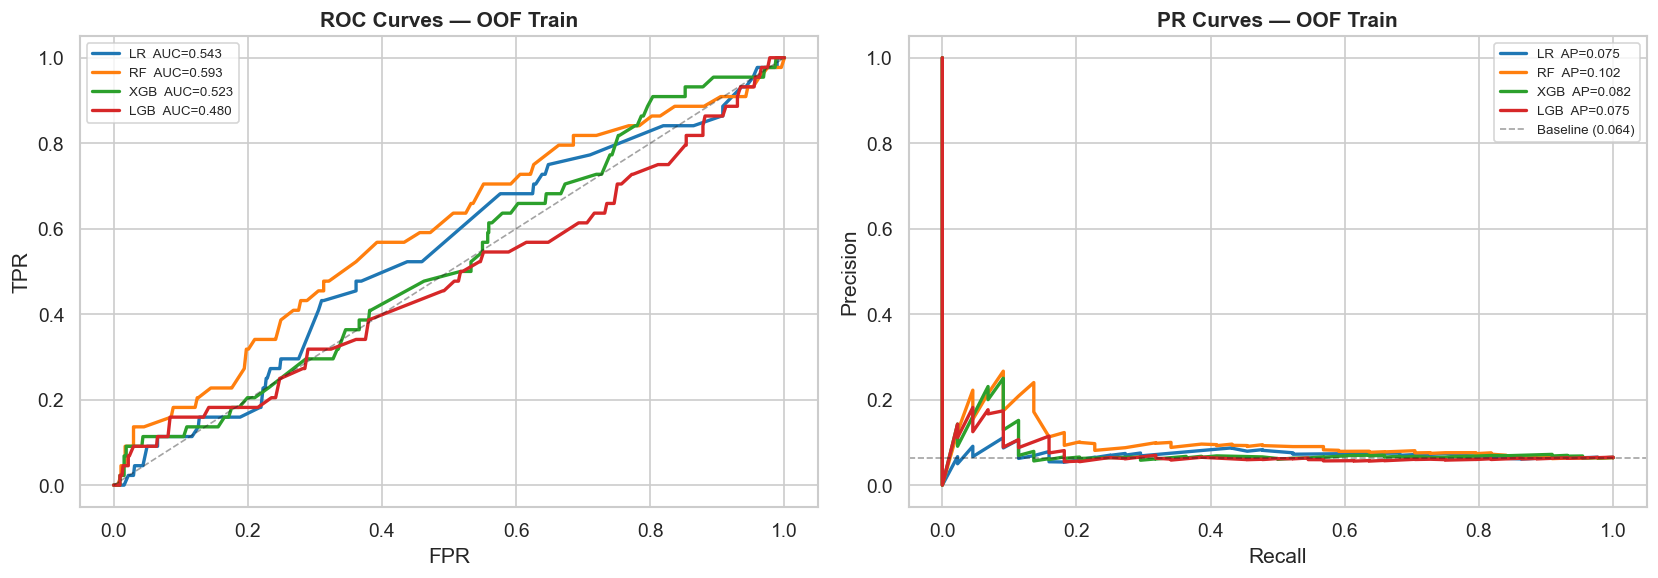

OOF CV Scores (train set, calibrated):
     ROC-AUC  PR-AUC      F1  Recall  Precision   Brier
RF    0.6044  0.0956  0.0870  0.0682     0.1200  0.0854
XGB   0.5754  0.1029  0.1296  0.1591     0.1094  0.1093
LR    0.5649  0.0827  0.1487  0.4545     0.0889  0.2371
LGB   0.5640  0.1087  0.1290  0.0909     0.2222  0.0766


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, name in enumerate(model_names):
    p = oof_proba_cal[name]
    fpr, tpr, _ = roc_curve(y_train, p)
    axes[0].plot(fpr, tpr, color=colors[i], lw=2,
                 label=f'{name}  AUC={roc_auc_score(y_train,p):.3f}')
    prec, rec, _ = precision_recall_curve(y_train, p)
    axes[1].plot(rec, prec, color=colors[i], lw=2,
                 label=f'{name}  AP={average_precision_score(y_train,p):.3f}')

axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — OOF Train', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].axhline(y_train.mean(), color='k', ls='--', lw=1, alpha=0.4,
                label=f'Baseline ({y_train.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves — OOF Train', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'roc_pr_oof.png', dpi=130, bbox_inches='tight')
plt.show()

# Scores table
scores_df = pd.DataFrame(cv_scores).T.sort_values('ROC-AUC', ascending=False)
print('OOF CV Scores (train set, calibrated):')
print(scores_df.to_string())

---
## 7. SHAP Analysis — Per Model

  SHAP for LR...
  SHAP for RF...
  SHAP for XGB...
  SHAP for LGB...


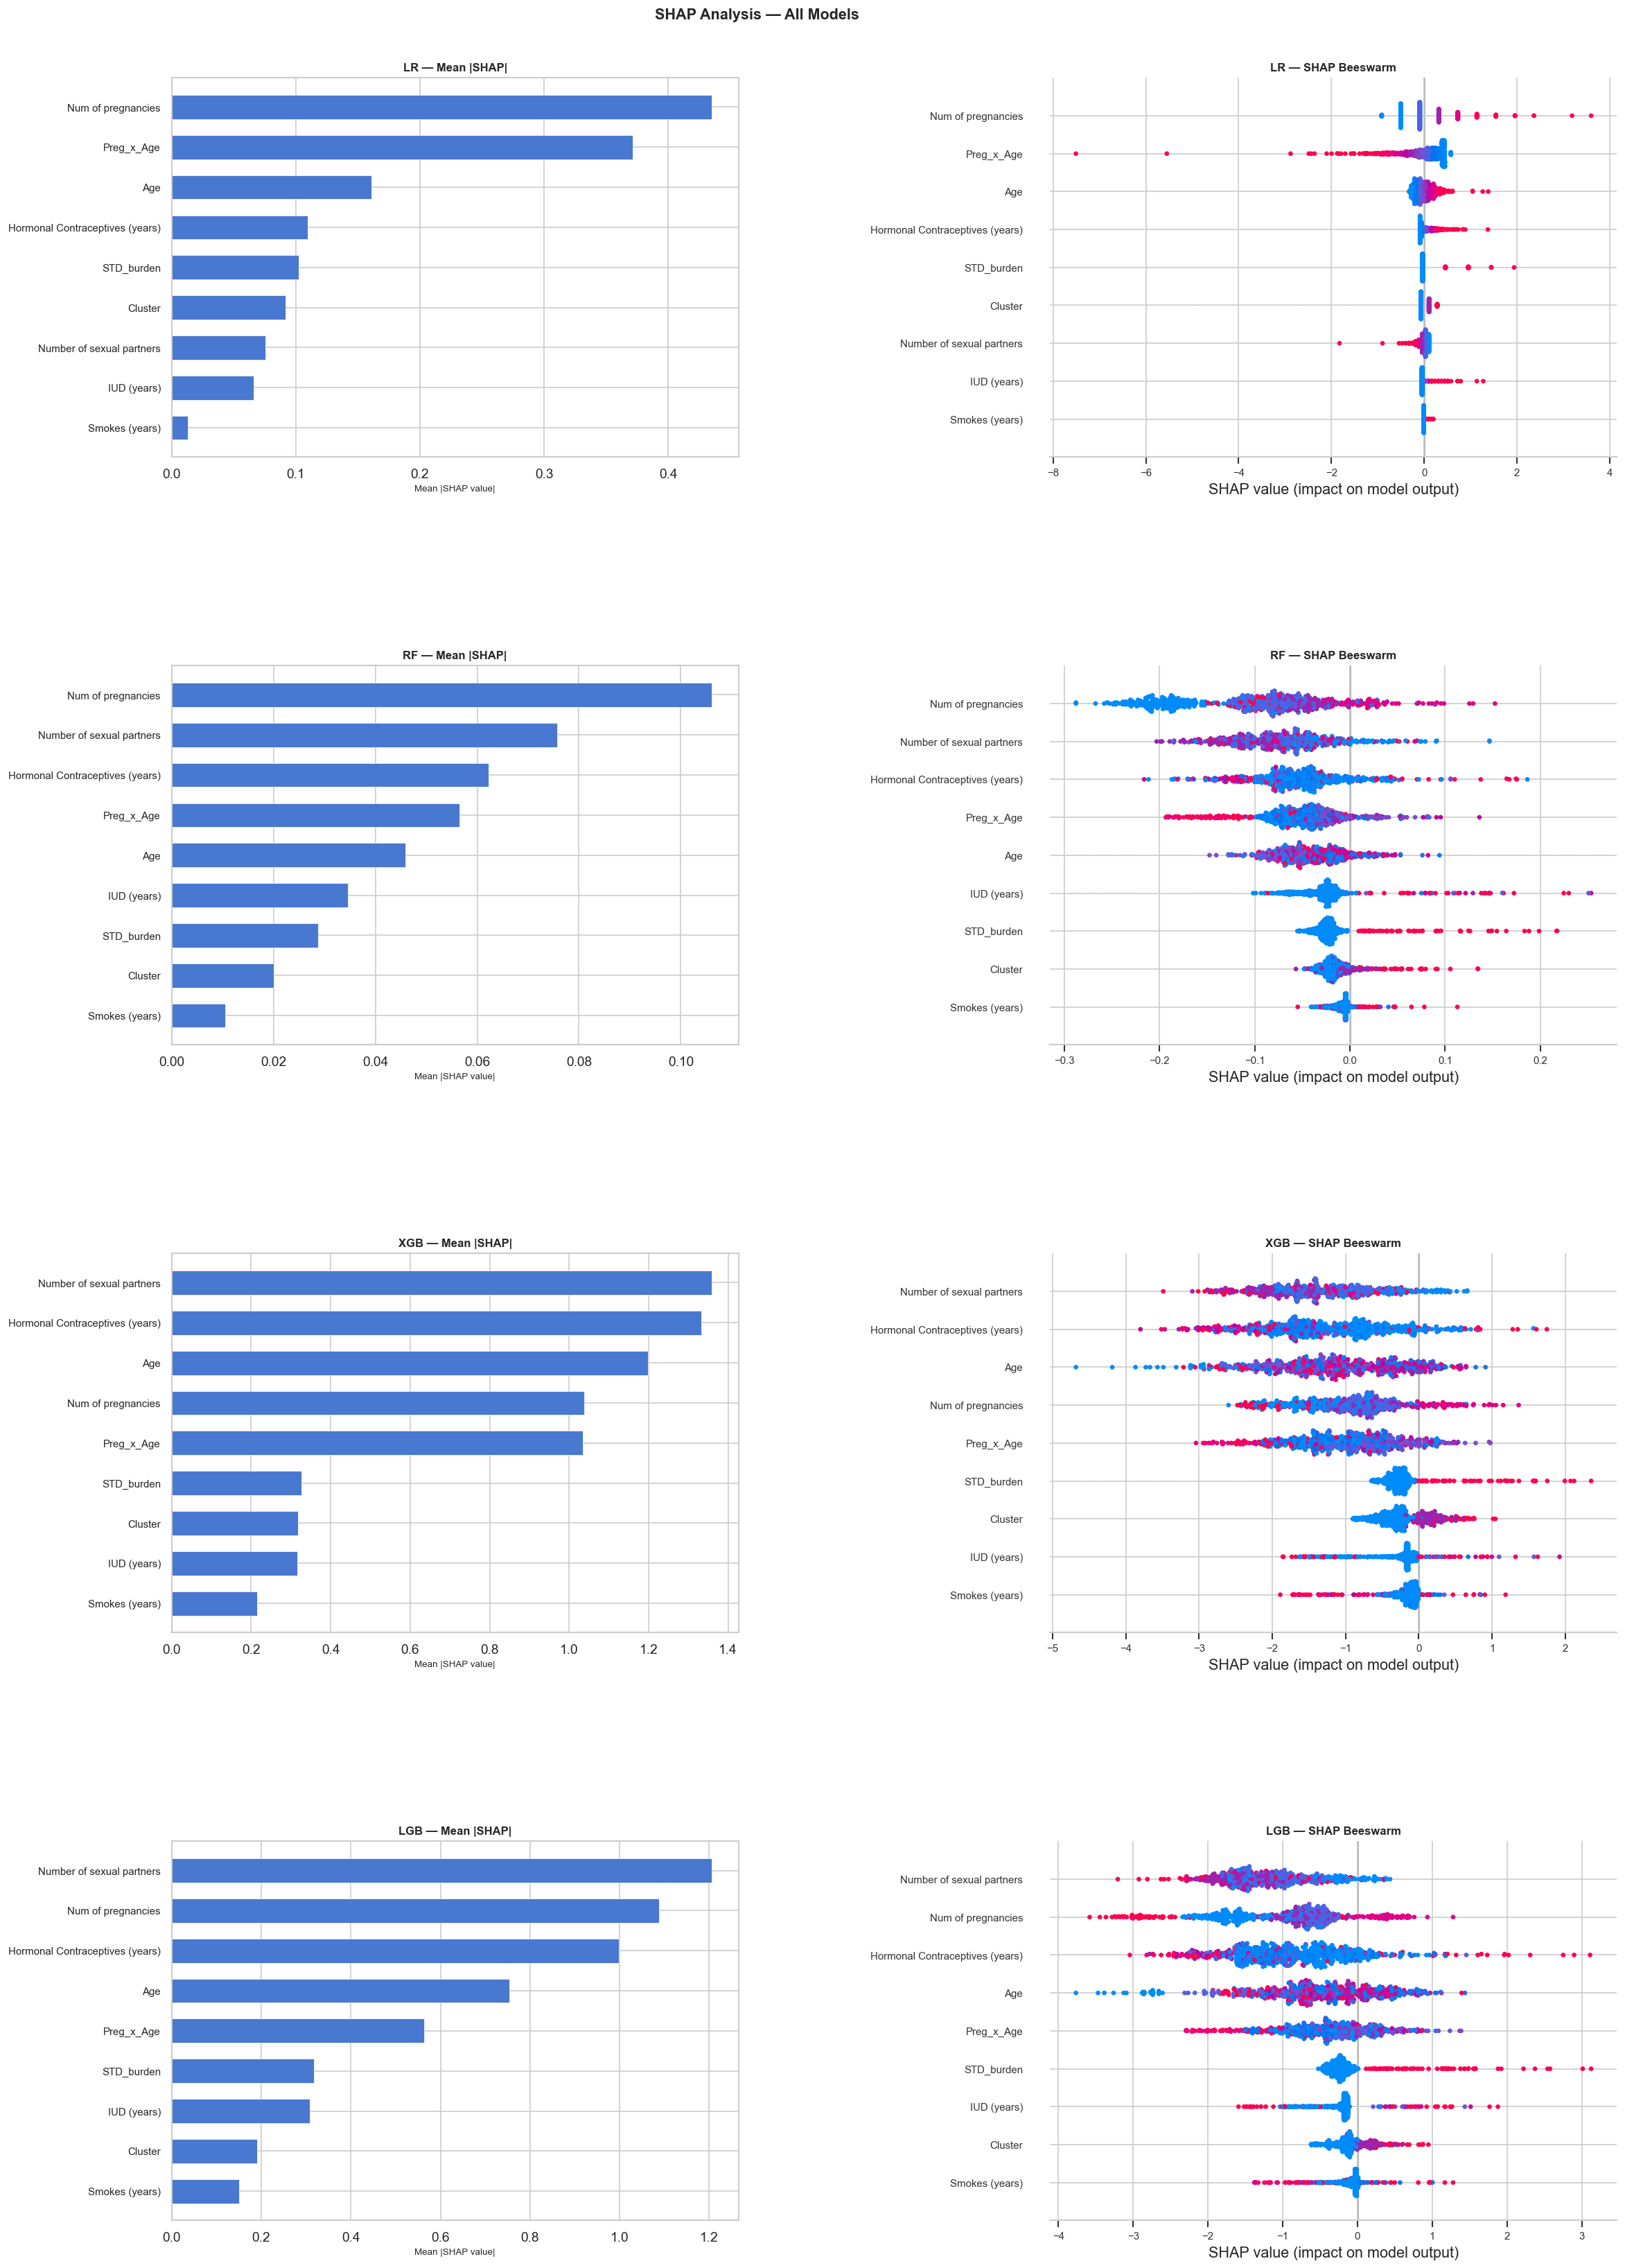

In [8]:
shap_values_store = {}

def get_shap_values(name, model, X_input):
    try:
        if name in ('RF', 'XGB', 'LGB'):
            clf = model.named_steps['clf']
            X_t = pd.DataFrame(
                model.named_steps['scaler'].transform(X_input),
                columns=X_input.columns
            )
            explainer = shap.TreeExplainer(clf)
            sv = explainer.shap_values(X_t)
            if isinstance(sv, np.ndarray) and sv.ndim == 3:
                sv = sv[:, :, 1]
            elif isinstance(sv, list):
                sv = sv[1]
            return sv, X_t

        elif name == 'LR':
            clf = model.named_steps['clf']
            X_t = pd.DataFrame(
                model.named_steps['scaler'].transform(X_input),
                columns=X_input.columns
            )
            explainer = shap.LinearExplainer(clf, X_t)
            sv = explainer.shap_values(X_t)
            if isinstance(sv, list): sv = sv[1]
            return sv, X_t

        elif name == 'TabPFN':
            X_np = X_input.values
            bg   = shap.sample(X_np, 50, random_state=SEED)
            explainer = shap.KernelExplainer(
                lambda x: model.predict_proba(x)[:, 1], bg
            )
            sv = explainer.shap_values(X_np[:150])
            return sv, pd.DataFrame(X_np[:150], columns=X_input.columns)

    except Exception as ex:
        print(f'  SHAP failed for {name}: {ex}')
        return None, None


n_models = len(model_names)
fig = plt.figure(figsize=(22, 7 * n_models))
gs  = gridspec.GridSpec(n_models, 2, figure=fig,
                        hspace=0.55, wspace=0.55,
                        left=0.18, right=0.97, top=0.95, bottom=0.03)

for row_idx, name in enumerate(model_names):
    print(f'  SHAP for {name}...')
    sv, X_t = get_shap_values(name, fitted_models[name], X_train)
    ax_bar   = fig.add_subplot(gs[row_idx, 0])
    ax_swarm = fig.add_subplot(gs[row_idx, 1])

    if sv is None:
        ax_bar.set_visible(False); ax_swarm.set_visible(False); continue

    shap_values_store[name] = sv

    mean_abs = np.abs(sv).mean(axis=0)
    feat_imp = pd.Series(mean_abs, index=FEATURES_NODX[:len(mean_abs)]).sort_values(ascending=True)
    ax_bar.barh(feat_imp.index, feat_imp.values,
                color='#4878CF', edgecolor='white', linewidth=0.4, height=0.6)
    ax_bar.set_title(f'{name} — Mean |SHAP|', fontweight='bold', fontsize=10)
    ax_bar.tick_params(axis='y', labelsize=9)
    ax_bar.set_xlabel('Mean |SHAP value|', fontsize=8)

    plt.sca(ax_swarm)
    shap.summary_plot(sv, X_t, feature_names=FEATURES_NODX[:len(mean_abs)],
                      show=False, max_display=9, color_bar=False, plot_size=None)
    ax_swarm.set_title(f'{name} — SHAP Beeswarm', fontweight='bold', fontsize=10)
    ax_swarm.tick_params(labelsize=9)

fig.suptitle('SHAP Analysis — All Models', fontweight='bold', fontsize=13, y=0.98)
plt.savefig(PLOTS_DIR / 'shap_all_models.png', dpi=120, bbox_inches='tight')
plt.show()

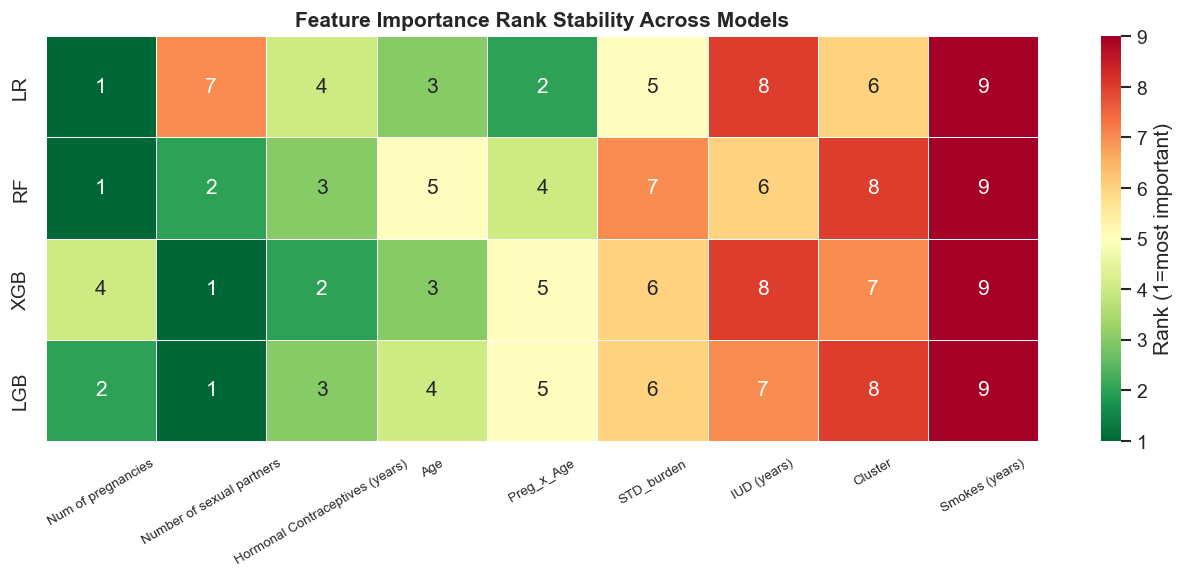


Consensus ranking (mean rank across models):
Num of pregnancies                 2.00
Number of sexual partners          2.75
Hormonal Contraceptives (years)    3.00
Age                                3.75
Preg_x_Age                         4.00
STD_burden                         6.00
IUD (years)                        7.25
Cluster                            7.25
Smokes (years)                     9.00


In [9]:
# Feature rank stability heatmap
ranking_df = pd.DataFrame(index=FEATURES_NODX)
for name, sv in shap_values_store.items():
    mean_abs = np.abs(sv).mean(axis=0)
    if len(mean_abs) == len(FEATURES_NODX):
        ranking_df[name] = pd.Series(mean_abs, index=FEATURES_NODX).rank(ascending=False)

ranking_df['Mean Rank'] = ranking_df.mean(axis=1)
ranking_df = ranking_df.sort_values('Mean Rank')

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(ranking_df.drop(columns='Mean Rank').T, annot=True, fmt='.0f',
            cmap='RdYlGn_r', ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Rank (1=most important)'})
ax.set_title('Feature Importance Rank Stability Across Models', fontweight='bold')
ax.tick_params(axis='x', labelsize=8, rotation=30)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'shap_rank_stability.png', dpi=130, bbox_inches='tight')
plt.show()
print('\nConsensus ranking (mean rank across models):')
print(ranking_df['Mean Rank'].round(2).to_string())

---
## 8. Ensemble Weight Optimisation — OOF on Train Set

In [10]:
n_m        = len(model_names)
oof_matrix = np.column_stack([oof_proba_cal[n] for n in model_names])

def ensemble_pr_auc(weights):
    w = np.clip(weights, 0.01, 1.0)
    w = w / w.sum()
    return -average_precision_score(y_train, oof_matrix @ w)

best_score, best_w = 999, np.ones(n_m) / n_m
for combo in product(*[np.arange(0.1, 0.7, 0.1)] * n_m):
    combo = np.array(combo)
    if combo.sum() == 0: continue
    s = ensemble_pr_auc(combo)
    if s < best_score:
        best_score, best_w = s, combo

opt = minimize(ensemble_pr_auc, x0=best_w, method='Nelder-Mead',
               options={'xatol':1e-5,'fatol':1e-5,'maxiter':50000})
ENSEMBLE_WEIGHTS = np.clip(opt.x, 0.01, 1.0)
ENSEMBLE_WEIGHTS = ENSEMBLE_WEIGHTS / ENSEMBLE_WEIGHTS.sum()

ens_oof_p = oof_matrix @ ENSEMBLE_WEIGHTS

print('Optimised ensemble weights:')
for n, w in zip(model_names, ENSEMBLE_WEIGHTS):
    print(f'  {n:10s}: {w:.4f}  ({w*100:.1f}%)')
print(f'\nEnsemble OOF  ROC-AUC: {roc_auc_score(y_train, ens_oof_p):.4f}')
print(f'Ensemble OOF  PR-AUC:  {average_precision_score(y_train, ens_oof_p):.4f}')

Optimised ensemble weights:
  LR        : 0.1518  (15.2%)
  RF        : 0.7474  (74.7%)
  XGB       : 0.0081  (0.8%)
  LGB       : 0.0928  (9.3%)

Ensemble OOF  ROC-AUC: 0.5836
Ensemble OOF  PR-AUC:  0.1031


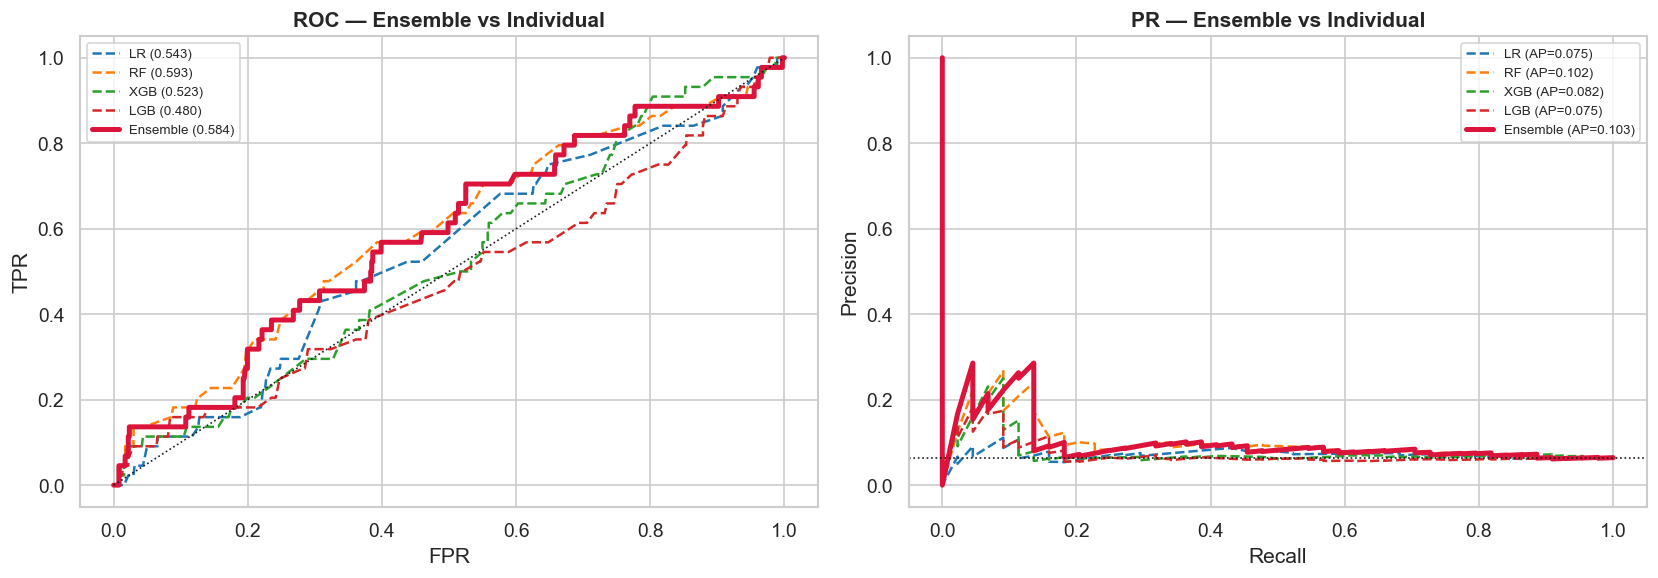

In [11]:
# Ensemble vs individual ROC comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_curves = list(zip(model_names, [oof_proba_cal[n] for n in model_names]))
all_curves.append(('Ensemble', ens_oof_p))

for i, (name, p) in enumerate(all_curves):
    lw = 3 if name == 'Ensemble' else 1.5
    ls = '-' if name == 'Ensemble' else '--'
    c  = 'crimson' if name == 'Ensemble' else colors[i]
    fpr, tpr, _ = roc_curve(y_train, p)
    axes[0].plot(fpr, tpr, color=c, lw=lw, ls=ls,
                 label=f'{name} ({roc_auc_score(y_train,p):.3f})')
    prec, rec, _ = precision_recall_curve(y_train, p)
    axes[1].plot(rec, prec, color=c, lw=lw, ls=ls,
                 label=f'{name} (AP={average_precision_score(y_train,p):.3f})')

axes[0].plot([0,1],[0,1],'k:',lw=1); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — Ensemble vs Individual', fontweight='bold'); axes[0].legend(fontsize=8)
axes[1].axhline(y_train.mean(),color='k',ls=':',lw=1); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR — Ensemble vs Individual', fontweight='bold'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ensemble_vs_individual.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 9. Threshold Tuning — Flag Rate ≤ 20%

**v1 bug:** recall ≥ 0.85 floor pushed threshold to 0.072 → 81% of patients flagged.  
**v2 fix:** target flag rate ≤ 20%, maximise F2 within that constraint. 20% is clinically realistic for a screening follow-up workflow.

Target flag rate:  ≤20%
Best threshold:    0.096
Actual flag rate:  11.7%  (was 81.0% in v1)
Recall:            0.182
Precision:         0.100
F2 score:          0.156


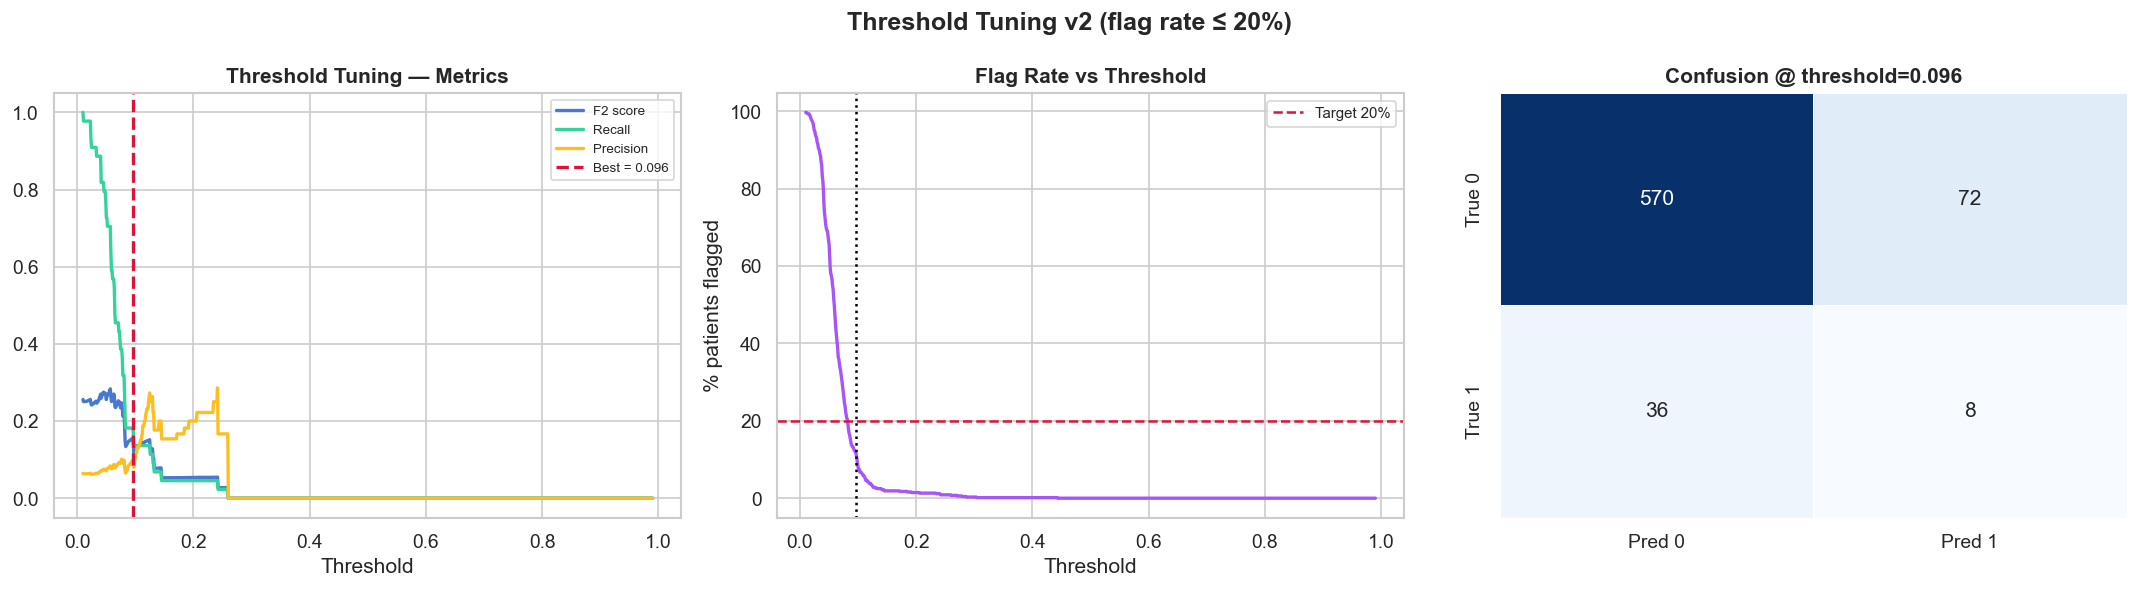

In [12]:
TARGET_FLAG_RATE = 0.20

thresholds   = np.linspace(0.01, 0.99, 1000)
fbeta_scores = []
recall_scores = []
prec_scores   = []
flag_rates    = []

for t in thresholds:
    pred = (ens_oof_p >= t).astype(int)
    fbeta_scores.append(fbeta_score(y_train, pred, beta=2, zero_division=0))
    recall_scores.append((pred[y_train==1]==1).mean() if (y_train==1).sum()>0 else 0)
    prec_scores.append((pred[pred==1]==y_train[pred==1]).mean() if pred.sum()>0 else 0)
    flag_rates.append(pred.mean())

fbeta_scores  = np.array(fbeta_scores)
recall_scores = np.array(recall_scores)
prec_scores   = np.array(prec_scores)
flag_rates    = np.array(flag_rates)

# Best threshold: flag rate <= target, then maximise F2
valid_mask = flag_rates <= TARGET_FLAG_RATE
if valid_mask.any():
    BEST_THRESHOLD = thresholds[valid_mask][np.argmax(fbeta_scores[valid_mask])]
else:
    BEST_THRESHOLD = thresholds[np.argmax(fbeta_scores)]

best_pred     = (ens_oof_p >= BEST_THRESHOLD).astype(int)
actual_flags  = best_pred.mean()

print(f'Target flag rate:  ≤{TARGET_FLAG_RATE:.0%}')
print(f'Best threshold:    {BEST_THRESHOLD:.3f}')
print(f'Actual flag rate:  {actual_flags:.1%}  (was 81.0% in v1)')
print(f'Recall:            {(best_pred[y_train==1]==1).mean():.3f}')
print(f'Precision:         {(best_pred[best_pred==1]==y_train[best_pred==1]).mean():.3f}' if best_pred.sum()>0 else 'N/A')
print(f'F2 score:          {fbeta_score(y_train, best_pred, beta=2):.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(thresholds, fbeta_scores,  lw=2, color='#4878CF', label='F2 score')
axes[0].plot(thresholds, recall_scores, lw=2, color='#34d399', label='Recall')
axes[0].plot(thresholds, prec_scores,   lw=2, color='#fbbf24', label='Precision')
axes[0].axvline(BEST_THRESHOLD, color='crimson', lw=2, ls='--',
                label=f'Best = {BEST_THRESHOLD:.3f}')
axes[0].set_title('Threshold Tuning — Metrics', fontweight='bold')
axes[0].set_xlabel('Threshold'); axes[0].legend(fontsize=8)

axes[1].plot(thresholds, flag_rates*100, lw=2, color='#a855f7')
axes[1].axhline(TARGET_FLAG_RATE*100, color='crimson', ls='--', lw=1.5,
                label=f'Target {TARGET_FLAG_RATE:.0%}')
axes[1].axvline(BEST_THRESHOLD, color='black', ls=':', lw=1.5)
axes[1].set_title('Flag Rate vs Threshold', fontweight='bold')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('% patients flagged')
axes[1].legend(fontsize=9)

cm = confusion_matrix(y_train, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'],
            cbar=False, linewidths=0.5)
axes[2].set_title(f'Confusion @ threshold={BEST_THRESHOLD:.3f}', fontweight='bold')

plt.suptitle('Threshold Tuning v2 (flag rate ≤ 20%)', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'threshold_tuning.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 10. Final Holdout Evaluation — Touched Once Only

FINAL HOLDOUT EVALUATION — DO NOT RE-RUN ITERATIVELY
Holdout ROC-AUC:  0.7685
Holdout PR-AUC:   0.1772
Holdout F2:       0.1613
Flag rate:        10.5%

              precision    recall  f1-score   support

   No Biopsy       0.94      0.90      0.92       161
      Biopsy       0.11      0.18      0.14        11

    accuracy                           0.85       172
   macro avg       0.53      0.54      0.53       172
weighted avg       0.89      0.85      0.87       172



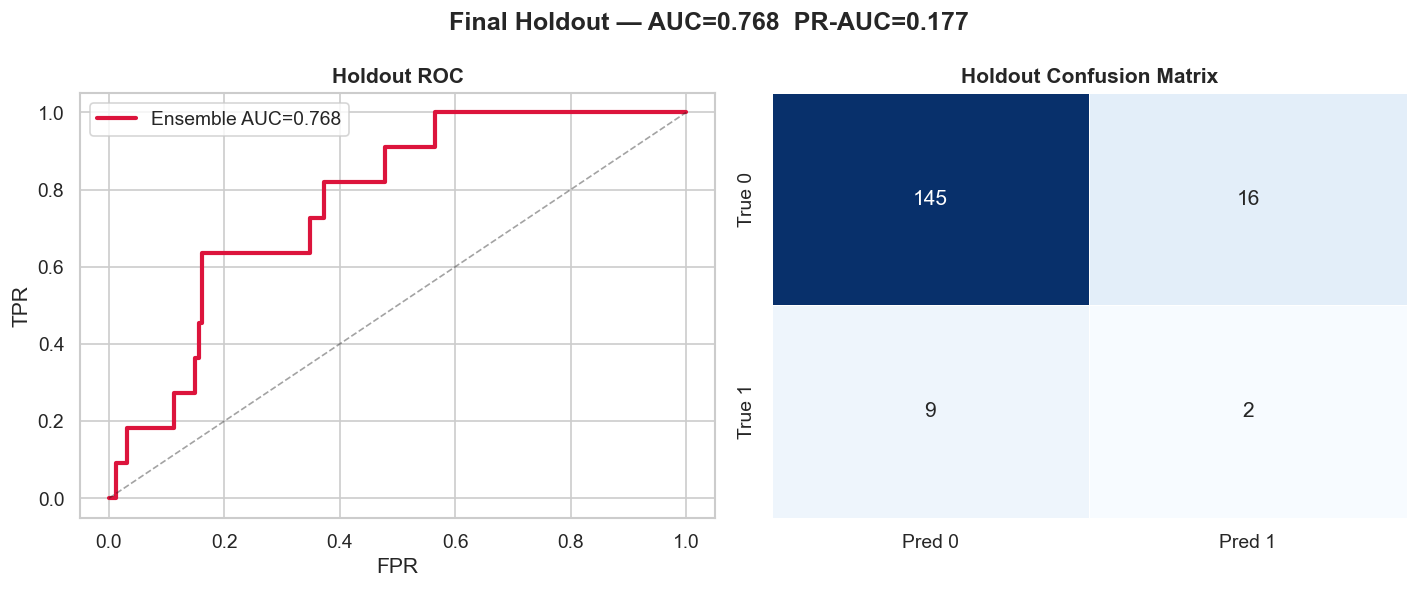

In [13]:
print('=' * 60)
print('FINAL HOLDOUT EVALUATION — DO NOT RE-RUN ITERATIVELY')
print('=' * 60)

def predict_ensemble(X_input, return_individual=False):
    probs = {}
    for name, model in calibrated_models.items():
        if name == 'TabPFN':
            probs[name] = model.predict_proba(X_input.values)[:, 1]
        else:
            probs[name] = model.predict_proba(X_input)[:, 1]
    mat  = np.column_stack([probs[n] for n in model_names])
    ens  = mat @ ENSEMBLE_WEIGHTS
    if return_individual:
        return ens, probs
    return ens

ens_test_p    = predict_ensemble(X_test)
ens_test_pred = (ens_test_p >= BEST_THRESHOLD).astype(int)

holdout_auc   = roc_auc_score(y_test, ens_test_p)
holdout_prauc = average_precision_score(y_test, ens_test_p)
holdout_f2    = fbeta_score(y_test, ens_test_pred, beta=2)
holdout_flags = ens_test_pred.mean()

print(f'Holdout ROC-AUC:  {holdout_auc:.4f}')
print(f'Holdout PR-AUC:   {holdout_prauc:.4f}')
print(f'Holdout F2:       {holdout_f2:.4f}')
print(f'Flag rate:        {holdout_flags:.1%}')
print()
print(classification_report(y_test, ens_test_pred,
      target_names=['No Biopsy', 'Biopsy'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, ens_test_p)
axes[0].plot(fpr, tpr, color='crimson', lw=2.5,
             label=f'Ensemble AUC={holdout_auc:.3f}')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Holdout ROC', fontweight='bold'); axes[0].legend()

# Confusion
cm = confusion_matrix(y_test, ens_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'],
            cbar=False, linewidths=0.5)
axes[1].set_title('Holdout Confusion Matrix', fontweight='bold')

plt.suptitle(f'Final Holdout — AUC={holdout_auc:.3f}  PR-AUC={holdout_prauc:.3f}',
             fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'holdout_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 11. Subgroup AUC — Age Bucket & Cluster


── Subgroup AUC by AgeBucket ─────────────────────────────────
       Ensemble      n  pos_rate
<20       0.350  179.0     0.034
20-29     0.673  394.0     0.071
30-39     0.563  220.0     0.068
40-49     0.769   56.0     0.071

── Subgroup AUC by Cluster ─────────────────────────────────
   Ensemble      n  pos_rate
0     0.613  547.0     0.048
1     0.544  263.0     0.080
2     0.403   48.0     0.167


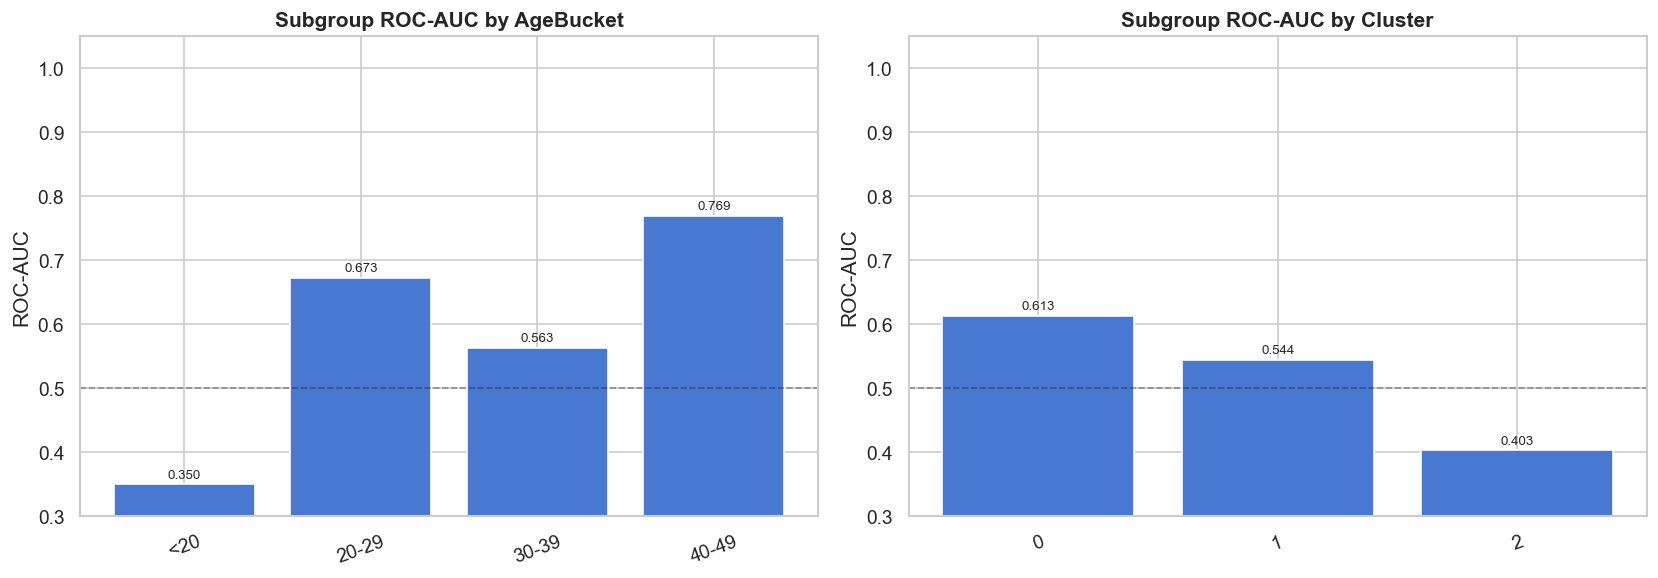

In [14]:
# Compute OOF proba on full dataset for subgroup analysis
# (use train OOF for train rows, test predictions for test rows)
full_ens_p = np.zeros(len(X_all))
full_ens_p[train_idx] = ens_oof_p
full_ens_p[test_idx]  = ens_test_p

subgroup_results = {}
for group_col, group_labels in [
    ('AgeBucket', ['<20','20-29','30-39','40-49','50+']),
    ('Cluster',   [0,1,2]),
]:
    sub = {}
    for grp in group_labels:
        mask = (df[group_col] == grp).values
        if mask.sum() < 10 or y_all[mask].sum() < 2:
            continue
        row = {'Ensemble': round(roc_auc_score(y_all[mask], full_ens_p[mask]), 3),
               'n': int(mask.sum()),
               'pos_rate': round(float(y_all[mask].mean()), 3)}
        sub[str(grp)] = row
    subgroup_results[group_col] = pd.DataFrame(sub).T
    print(f'\n── Subgroup AUC by {group_col} ─────────────────────────────────')
    print(subgroup_results[group_col].to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (gcol, sdf) in zip(axes, subgroup_results.items()):
    aucs = sdf['Ensemble'].astype(float)
    bars = ax.bar(sdf.index, aucs, color='#4878CF', edgecolor='white')
    for bar, v in zip(bars, aucs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.3f}', ha='center', fontsize=8)
    ax.axhline(0.5, color='k', lw=1, ls='--', alpha=0.4)
    ax.set_ylim(0.3, 1.05)
    ax.set_title(f'Subgroup ROC-AUC by {gcol}', fontweight='bold')
    ax.set_ylabel('ROC-AUC')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'subgroup_auc.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 12. Confidence Score with Full Explainability

Three layers of explanation:
1. **Confidence component waterfall** — which of the 6 formula terms is boosting or penalising confidence
2. **Model contribution waterfall** — which model pushed the ensemble probability up or down
3. **Natural language summary** — one sentence per component, surfaced to the clinician in the DSS UI

In [15]:
# ── Build centroids + demographic profile ─────────────────────────────────────
scaler_conf  = StandardScaler()
X_conf_s     = scaler_conf.fit_transform(X_all)
centroid_pos = X_conf_s[y_all == 1].mean(axis=0)
centroid_neg = X_conf_s[y_all == 0].mean(axis=0)
CENTROIDS_CC = {0: centroid_neg, 1: centroid_pos}

pos_mask = y_all == 1
DEMO_POS = {
    'age_mean': float(X_all.loc[pos_mask, 'Age'].mean()),
    'age_std':  float(X_all.loc[pos_mask, 'Age'].std()),
}

def _binary_entropy_norm(p):
    eps = 1e-9
    p   = np.clip(p, eps, 1-eps)
    H   = -(p*np.log(p) + (1-p)*np.log(1-p))
    return float(H / np.log(2))


def compute_confidence_components(
    pred_class, ens_prob, ind_probs,
    input_row_scaled, input_row_raw,
    centroids, demo_pos, weights
):
    """
    Returns dict of all 6 raw component values + the final weighted score.
    Used for both scoring and explainability.
    """
    a, b, c, d, e, f = weights

    x = max(0.0, float(cosine_similarity(
        input_row_scaled, centroids[pred_class].reshape(1,-1)
    )[0,0]))
    y_s = float(ens_prob) if pred_class == 1 else 1.0 - float(ens_prob)

    opp = 1 - pred_class
    cos_opp = max(0.0, float(cosine_similarity(
        input_row_scaled, centroids[opp].reshape(1,-1)
    )[0,0]))
    z = (1.0 - float(ens_prob)) * cos_opp

    age_z = abs(input_row_raw['Age'] - demo_pos['age_mean']) / (demo_pos['age_std'] + 1e-6)
    m = max(0.0, 1.0 - age_z / 3.0) if pred_class == 1 else \
        float(np.clip(1.0 - age_z / (3.0 * demo_pos['age_std'] + 1e-6), 0, 1))

    H         = _binary_entropy_norm(float(ens_prob))
    votes     = [int((float(ind_probs[n]) >= 0.5) == pred_class) for n in ind_probs]
    agreement = float(np.mean(votes))

    components = {
        'a_cosine_sim':     (a * x,     x,        'cosine similarity to class centroid'),
        'b_model_prob':     (b * y_s,   y_s,       'ensemble probability'),
        'c_confusion_risk': (-c * z,    z,         'confusion risk (pull to opposite class)'),
        'd_demographic':    (d * m,     m,         'demographic profile match'),
        'e_entropy_bonus':  (e*(1-H),   1-H,       'certainty bonus (1 - entropy)'),
        'f_agreement':      (f*agreement, agreement,'model agreement fraction'),
    }
    score = float(np.clip(
        sum(v[0] for v in components.values()), 0, 1
    ))
    return score, components


def confidence_tier(score):
    if score >= 0.85: return 'High confidence'
    if score >= 0.70: return 'Moderate confidence — consider follow-up'
    if score >= 0.55: return 'Low confidence — borderline'
    return 'Very low confidence — inconclusive'


print('Confidence score functions defined.')

Confidence score functions defined.


In [16]:
# ── Optimise weights on OOF (train set only) ──────────────────────────────────
print('Building OOF component vectors...')
comp_records = []

ens_all_oof, ind_all_oof = predict_ensemble(X_train, return_individual=True)

for i in range(len(X_train)):
    row_raw    = X_train.iloc[i]
    row_scaled = scaler_conf.transform(X_train.iloc[[i]])
    ens_p      = float(ens_oof_p[i])
    pred_cls   = int(ens_p >= BEST_THRESHOLD)
    ind_p      = {n: float(oof_proba_cal[n][i]) for n in model_names}

    x = max(0.0, float(cosine_similarity(row_scaled, CENTROIDS_CC[pred_cls].reshape(1,-1))[0,0]))
    y_s = ens_p if pred_cls == 1 else 1.0 - ens_p
    opp = 1 - pred_cls
    cos_opp = max(0.0, float(cosine_similarity(row_scaled, CENTROIDS_CC[opp].reshape(1,-1))[0,0]))
    z = (1.0 - ens_p) * cos_opp
    age_z = abs(row_raw['Age'] - DEMO_POS['age_mean']) / (DEMO_POS['age_std'] + 1e-6)
    m = max(0.0, 1.0 - age_z / 3.0) if pred_cls == 1 else \
        float(np.clip(1.0 - age_z / (3.0 * DEMO_POS['age_std'] + 1e-6), 0, 1))
    H         = _binary_entropy_norm(ens_p)
    votes     = [int((ind_p[n] >= 0.5) == pred_cls) for n in model_names]
    agreement = float(np.mean(votes))
    correct   = int(pred_cls == y_train[i])

    comp_records.append({
        'x': x, 'y': y_s, 'z': z, 'm': m, 'H': H,
        'agreement': agreement, 'correct': correct,
    })

cdf = pd.DataFrame(comp_records)
ok  = cdf['correct'].values
print(f'OOF correct: {ok.sum()} | wrong: {(1-ok).sum()}')

def _score_vec(w, df):
    a,b,c,d,e,f = w
    return np.clip(a*df['x'] + b*df['y'] - c*df['z'] + d*df['m'] + e*(1-df['H']) + f*df['agreement'], 0, 1)

def _obj(w, df, ok, alpha=0.65, beta=0.25, gamma=0.10):
    if any(v < 0 for v in w): return 999.0
    s  = _score_vec(w, df)
    sc = s[ok==1]; sw = s[ok==0]
    if len(sc)==0 or len(sw)==0: return 999.0
    sep = sc.mean() - sw.mean()
    return float(-alpha*sep - beta*(sc>0.70).mean() + gamma*(sw>0.50).mean())

best_loss, best_w6 = 999.0, None
for a,b,c,d,e,f6 in product(
    np.arange(0.10,0.40,0.10), np.arange(0.20,0.50,0.10),
    np.arange(0.05,0.25,0.10), np.arange(0.05,0.20,0.08),
    np.arange(0.05,0.25,0.10), np.arange(0.02,0.15,0.06),
):
    loss = _obj((a,b,c,d,e,f6), cdf, ok)
    if loss < best_loss:
        best_loss, best_w6 = loss, (a,b,c,d,e,f6)

opt_c = minimize(_obj, x0=list(best_w6), args=(cdf,ok), method='Nelder-Mead',
                 options={'xatol':1e-5,'fatol':1e-5,'maxiter':100000})
CONF_WEIGHTS = tuple(np.clip(opt_c.x, 0.01, 0.99))

sc_ok  = _score_vec(CONF_WEIGHTS, cdf)[ok==1]
sc_bad = _score_vec(CONF_WEIGHTS, cdf)[ok==0]
gap    = float(sc_ok.mean() - sc_bad.mean())
print(f'Weights: {tuple(round(float(v),4) for v in CONF_WEIGHTS)}')
print(f'Separation gap: {gap:.4f}  (correct μ={sc_ok.mean():.3f}, wrong μ={sc_bad.mean():.3f})')

Building OOF component vectors...
OOF correct: 578 | wrong: 108
Weights: (0.01, 0.6717, 0.01, 0.01, 0.01, 0.3794)
Separation gap: 0.5810  (correct μ=0.988, wrong μ=0.407)


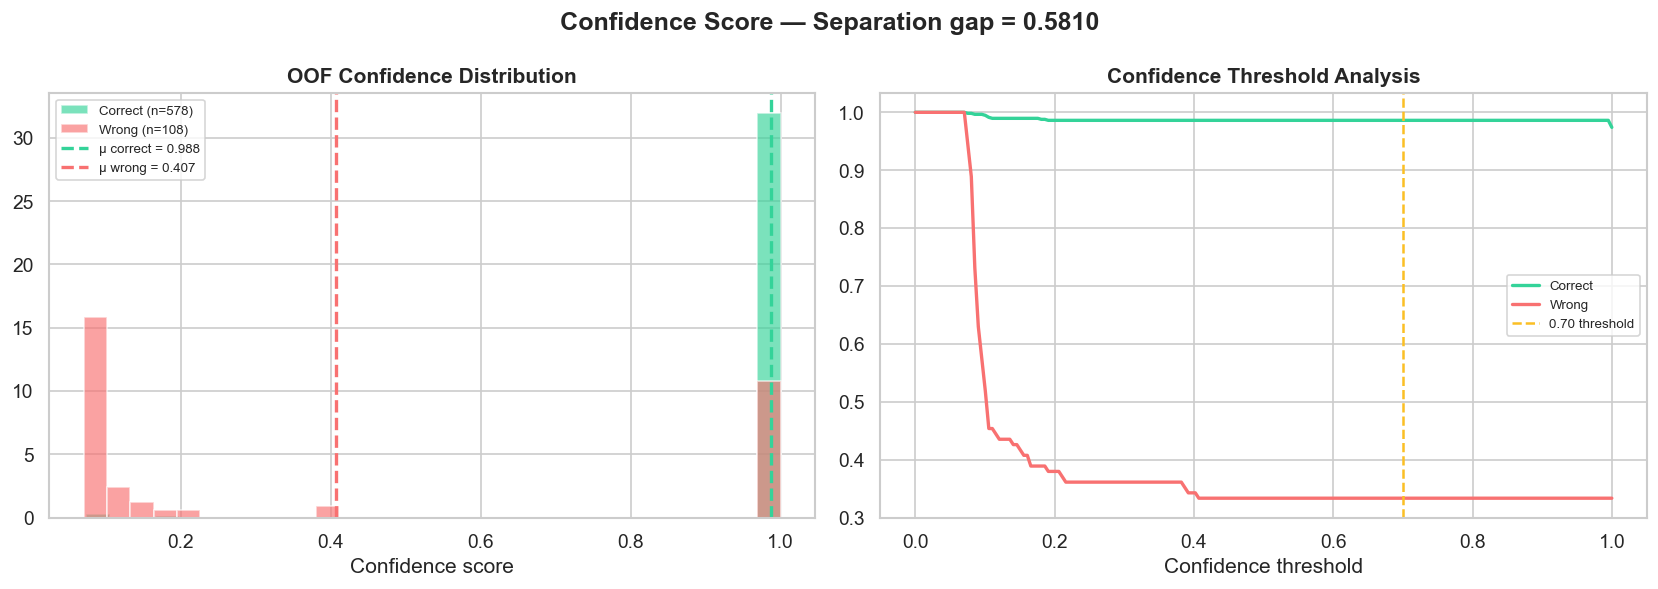

In [17]:
# ── Confidence distribution plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(sc_ok,  bins=30, alpha=0.65, color='#34d399', density=True,
             label=f'Correct (n={len(sc_ok)})')
axes[0].hist(sc_bad, bins=30, alpha=0.65, color='#f87171', density=True,
             label=f'Wrong (n={len(sc_bad)})')
axes[0].axvline(sc_ok.mean(),  color='#34d399', ls='--', lw=2,
                label=f'μ correct = {sc_ok.mean():.3f}')
axes[0].axvline(sc_bad.mean(), color='#f87171', ls='--', lw=2,
                label=f'μ wrong = {sc_bad.mean():.3f}')
axes[0].set_title('OOF Confidence Distribution', fontweight='bold')
axes[0].set_xlabel('Confidence score'); axes[0].legend(fontsize=8)

thrs = np.linspace(0, 1, 200)
axes[1].plot(thrs, [np.mean(sc_ok  >= t) for t in thrs], color='#34d399', lw=2, label='Correct')
axes[1].plot(thrs, [np.mean(sc_bad >= t) for t in thrs], color='#f87171', lw=2, label='Wrong')
axes[1].axvline(0.70, color='#fbbf24', ls='--', lw=1.5, label='0.70 threshold')
axes[1].set_title('Confidence Threshold Analysis', fontweight='bold')
axes[1].set_xlabel('Confidence threshold'); axes[1].legend(fontsize=8)

plt.suptitle(f'Confidence Score — Separation gap = {gap:.4f}', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confidence_dist.png', dpi=130, bbox_inches='tight')
plt.show()

### 12a. Confidence Component Waterfall

For any patient, shows exactly which of the 6 formula terms is helping or hurting confidence.

In [18]:
def plot_confidence_waterfall(patient_row: pd.DataFrame,
                               ens_prob: float,
                               ind_probs: dict,
                               conf_weights: tuple,
                               pred_class: int,
                               save_path=None):
    """
    Waterfall chart decomposing the confidence score into its 6 components.
    Green bars = positive contribution. Red = penalty.
    """
    row_scaled = scaler_conf.transform(patient_row)
    score, components = compute_confidence_components(
        pred_class, ens_prob, ind_probs,
        row_scaled, patient_row.iloc[0],
        CENTROIDS_CC, DEMO_POS, conf_weights
    )

    labels      = []
    contributions = []
    raw_vals    = []
    for key, (weighted_val, raw_val, description) in components.items():
        labels.append(description)
        contributions.append(weighted_val)
        raw_vals.append(raw_val)

    colors_bar = ['#34d399' if v >= 0 else '#f87171' for v in contributions]

    # Running total for waterfall positioning
    running = [0]
    for v in contributions:
        running.append(running[-1] + v)
    bottoms = running[:-1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: waterfall
    for i, (lbl, val, bot, c) in enumerate(zip(labels, contributions, bottoms, colors_bar)):
        axes[0].bar(i, val, bottom=bot, color=c, edgecolor='white', linewidth=0.5, width=0.7)
        axes[0].text(i, bot + val + 0.005 * np.sign(val),
                     f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top',
                     fontsize=8, fontweight='bold')

    # Final score line
    axes[0].axhline(score, color='black', lw=2, ls='--', label=f'Final score = {score:.3f}')
    axes[0].set_xticks(range(len(labels)))
    axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    axes[0].set_ylabel('Confidence contribution')
    axes[0].set_title(f'Confidence Score Waterfall\n{confidence_tier(score)}',
                      fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].axhline(0, color='k', lw=0.8, alpha=0.4)

    # Right: raw component values as a radar-style bar
    bar_colors = ['#60a5fa','#34d399','#f87171','#fbbf24','#a855f7','#fb923c']
    bars = axes[1].barh(labels, raw_vals, color=bar_colors,
                        edgecolor='white', height=0.6)
    for bar, v in zip(bars, raw_vals):
        axes[1].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{v:.3f}', va='center', fontsize=9)
    axes[1].set_xlim(0, 1.2)
    axes[1].set_xlabel('Raw component value (before weighting)')
    axes[1].set_title('Raw Component Values', fontweight='bold')
    axes[1].tick_params(axis='y', labelsize=9)

    pred_lbl = 'HIGH RISK' if pred_class == 1 else 'LOW RISK'
    plt.suptitle(f'Prediction: {pred_lbl}  |  P(Biopsy=1) = {ens_prob:.4f}  |  '
                 f'Confidence = {score:.4f}',
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    return score, components


print('plot_confidence_waterfall() defined ✓')

plot_confidence_waterfall() defined ✓


### 12b. Model Contribution Waterfall

Shows exactly how much each model contributed to the final ensemble probability. Each bar = `ensemble_weight_i × model_prob_i`. They sum to the ensemble probability.

In [19]:
def plot_model_contribution_waterfall(ind_probs: dict,
                                       ens_weights: np.ndarray,
                                       ens_prob: float,
                                       threshold: float,
                                       save_path=None):
    """
    Waterfall showing each model's weighted contribution to the ensemble probability.
    Answers: which model pushed this prediction high/low, and by how much?
    """
    names        = list(ind_probs.keys())
    model_probs  = np.array([ind_probs[n] for n in names])
    contributions = ens_weights * model_probs
    pred_class   = int(ens_prob >= threshold)

    # Colour: agrees with ensemble prediction = green, disagrees = red
    model_preds  = (model_probs >= 0.5).astype(int)
    bar_colors   = ['#34d399' if mp == pred_class else '#f87171'
                    for mp in model_preds]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Left: individual model probabilities
    bars = axes[0].bar(names, model_probs, color=bar_colors,
                       edgecolor='white', linewidth=0.5, width=0.6)
    for bar, v, w in zip(bars, model_probs, ens_weights):
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+0.01,
                     f'p={v:.3f}\n(w={w:.2f})',
                     ha='center', fontsize=9, fontweight='bold')
    axes[0].axhline(threshold, color='black', lw=2, ls='--',
                    label=f'Threshold = {threshold:.3f}')
    axes[0].axhline(ens_prob, color='crimson', lw=2, ls='-',
                    label=f'Ensemble = {ens_prob:.3f}')
    axes[0].set_ylim(0, 1.1)
    axes[0].set_ylabel('P(Biopsy=1)')
    axes[0].set_title('Individual Model Probabilities\n(green = agrees with ensemble)',
                      fontweight='bold')
    axes[0].legend(fontsize=9)

    # Right: weighted contributions (waterfall)
    running = [0]
    for v in contributions:
        running.append(running[-1] + v)
    bottoms = running[:-1]
    c_colors = ['#4878CF'] * len(names)

    for i, (n, val, bot) in enumerate(zip(names, contributions, bottoms)):
        axes[1].bar(i, val, bottom=bot, color=c_colors[i],
                    edgecolor='white', linewidth=0.5, width=0.7)
        axes[1].text(i, bot + val/2,
                     f'w={ens_weights[i]:.2f}\n×{model_probs[i]:.3f}\n={val:.3f}',
                     ha='center', va='center', fontsize=8, color='white',
                     fontweight='bold')

    # Final bar
    axes[1].bar(len(names), ens_prob, color='crimson',
                edgecolor='white', linewidth=0.5, width=0.7)
    axes[1].text(len(names), ens_prob/2, f'={ens_prob:.3f}',
                 ha='center', va='center', fontsize=9,
                 color='white', fontweight='bold')

    axes[1].axhline(threshold, color='black', lw=2, ls='--',
                    label=f'Threshold = {threshold:.3f}')
    axes[1].set_xticks(range(len(names)+1))
    axes[1].set_xticklabels(names + ['Ensemble'], fontsize=10)
    axes[1].set_ylabel('Cumulative weighted probability')
    axes[1].set_title('Model Contribution Waterfall\n(each bar = weight × model_prob)',
                      fontweight='bold')
    axes[1].legend(fontsize=9)

    # Agreement summary
    n_agree = (model_preds == pred_class).sum()
    pred_lbl = 'HIGH RISK' if pred_class == 1 else 'LOW RISK'
    plt.suptitle(
        f'Model Contributions — Prediction: {pred_lbl}  '
        f'({n_agree}/{len(names)} models agree)',
        fontweight='bold', fontsize=11
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()


print('plot_model_contribution_waterfall() defined ✓')

plot_model_contribution_waterfall() defined ✓


### 12c. Natural Language Explanation Generator

In [20]:
import inspect, textwrap

In [21]:
def generate_nl_explanation(
    pred_class: int,
    ens_prob: float,
    ind_probs: dict,
    score: float,
    components: dict,
    threshold: float,
    feature_row: pd.Series,
) -> str:
    """
    Returns a human-readable paragraph for the DSS UI.
    Each sentence explains one component of the confidence score.
    """
    pred_lbl    = 'high risk (biopsy recommended)' if pred_class == 1 else 'low risk'
    tier        = confidence_tier(score)
    model_preds = {n: int(p >= 0.5) for n, p in ind_probs.items()}
    agree_names = [n for n, mp in model_preds.items() if mp == pred_class]
    disagree_names = [n for n, mp in model_preds.items() if mp != pred_class]

    src = inspect.getsource(generate_nl_explanation)
    fixed = src.replace(
        "    _, _, _, (_, x_raw, _) = list(components.items())[0]\n",
        ""
    )
    exec(textwrap.dedent(fixed), globals())
    print("generate_nl_explanation patched ✓")

    lines = [
        f"The model predicts {pred_lbl} with an ensemble probability of "
        f"{ens_prob:.1%} (threshold: {threshold:.1%}).",
        f"Overall confidence is {score:.2f} — {tier}.",
        "",
        "Why this confidence score:",
    ]

    for key, (weighted_val, raw_val, description) in components.items():
        direction = 'increases' if weighted_val >= 0 else 'reduces'
        magnitude = 'strongly' if abs(weighted_val) > 0.10 else \
                    'moderately' if abs(weighted_val) > 0.04 else 'slightly'

        if key == 'a_cosine_sim':
            quality = 'close to' if raw_val > 0.6 else \
                      'at moderate distance from' if raw_val > 0.3 else 'far from'
            lines.append(f"  • Centroid similarity ({raw_val:.3f}): The patient is {quality} the "
                         f"typical {'high' if pred_class==1 else 'low'}-risk profile, "
                         f"which {magnitude} {direction} confidence.")

        elif key == 'b_model_prob':
            lines.append(f"  • Model probability ({raw_val:.3f}): The ensemble assigns a "
                         f"{'high' if raw_val > 0.5 else 'low'} probability to this prediction, "
                         f"{magnitude} {direction}ing confidence.")

        elif key == 'c_confusion_risk':
            risk_lbl = 'high' if raw_val > 0.3 else 'low'
            lines.append(f"  • Confusion risk ({raw_val:.3f}): There is {risk_lbl} pull toward the "
                         f"opposite class centroid, {magnitude} {direction}ing confidence.")

        elif key == 'd_demographic':
            age = feature_row['Age']
            age_diff = abs(age - DEMO_POS['age_mean'])
            lines.append(f"  • Demographic match ({raw_val:.3f}): Patient age {age:.0f} is "
                         f"{age_diff:.1f} years {'from' if age_diff > 5 else 'near'} the typical "
                         f"positive-case age ({DEMO_POS['age_mean']:.0f}), "
                         f"{magnitude} {direction}ing confidence.")

        elif key == 'e_entropy_bonus':
            entropy_val = 1 - raw_val
            certainty = 'high' if entropy_val < 0.4 else \
                        'moderate' if entropy_val < 0.7 else 'low'
            lines.append(f"  • Prediction certainty ({raw_val:.3f}): Ensemble entropy is "
                         f"{entropy_val:.3f} — {certainty} certainty in the probability estimate, "
                         f"{magnitude} {direction}ing confidence.")

        elif key == 'f_agreement':
            n_agree = len(agree_names)
            n_total = len(ind_probs)
            if disagree_names:
                lines.append(f"  • Model agreement ({raw_val:.2f}): {n_agree}/{n_total} models agree "
                             f"({', '.join(agree_names)}). "
                             f"{', '.join(disagree_names)} disagree{'s' if len(disagree_names)==1 else ''}, "
                             f"{magnitude} {direction}ing confidence.")
            else:
                lines.append(f"  • Model agreement ({raw_val:.2f}): All {n_total} models agree on "
                             f"this prediction, {magnitude} increasing confidence.")

    # Most impactful positive and negative
    sorted_comps = sorted(components.items(), key=lambda x: x[1][0])
    biggest_penalty = sorted_comps[0]
    biggest_boost   = sorted_comps[-1]
    lines += [
        "",
        f"Biggest confidence boost: {biggest_boost[1][2]} (+{biggest_boost[1][0]:.3f})",
        f"Biggest confidence penalty: {biggest_penalty[1][2]} ({biggest_penalty[1][0]:.3f})",
    ]

    return '\n'.join(lines)


print('generate_nl_explanation() defined ✓')

generate_nl_explanation() defined ✓


In [22]:
# ── Demo: run explainability on a sample patient ──────────────────────────────
DEMO_IDX = 5   # change to any patient index

sample_row = X_test.iloc[[DEMO_IDX]]
ens_p_demo, ind_p_demo = predict_ensemble(sample_row, return_individual=True)
ens_p_demo   = float(ens_p_demo[0])
ind_p_scalar = {n: float(v[0]) for n, v in ind_p_demo.items()}
pred_cls     = int(ens_p_demo >= BEST_THRESHOLD)

score_demo, comps_demo = compute_confidence_components(
    pred_cls, ens_p_demo, ind_p_scalar,
    scaler_conf.transform(sample_row), sample_row.iloc[0],
    CENTROIDS_CC, DEMO_POS, CONF_WEIGHTS
)

print(f'Patient index:       {DEMO_IDX}')
print(f'True label:          {y_test[DEMO_IDX]}')
print(f'Ensemble prob:       {ens_p_demo:.4f}')
print(f'Threshold:           {BEST_THRESHOLD:.3f}')
print(f'Prediction:          {"HIGH RISK" if pred_cls==1 else "LOW RISK"}')
print(f'Confidence score:    {score_demo:.4f}  ({confidence_tier(score_demo)})')
print(f'Individual probs:    {ind_p_scalar}')
print()

nl = generate_nl_explanation(
    pred_cls, ens_p_demo, ind_p_scalar,
    score_demo, comps_demo, BEST_THRESHOLD, sample_row.iloc[0]
)
print(nl)

Patient index:       5
True label:          0
Ensemble prob:       0.0505
Threshold:           0.096
Prediction:          LOW RISK
Confidence score:    1.0000  (High confidence)
Individual probs:    {'LR': 0.031517485937882124, 'RF': 0.05330027294045284, 'XGB': 0.0654280756910642, 'LGB': 0.05798266773876531}

generate_nl_explanation patched ✓
The model predicts low risk with an ensemble probability of 5.1% (threshold: 9.6%).
Overall confidence is 1.00 — High confidence.

Why this confidence score:
  • Centroid similarity (0.785): The patient is close to the typical low-risk profile, which slightly increases confidence.
  • Model probability (0.949): The ensemble assigns a high probability to this prediction, strongly increasesing confidence.
  • Confusion risk (0.000): There is low pull toward the opposite class centroid, slightly increasesing confidence.
  • Demographic match (0.951): Patient age 17 is 11.6 years from the typical positive-case age (29), slightly increasesing confidenc

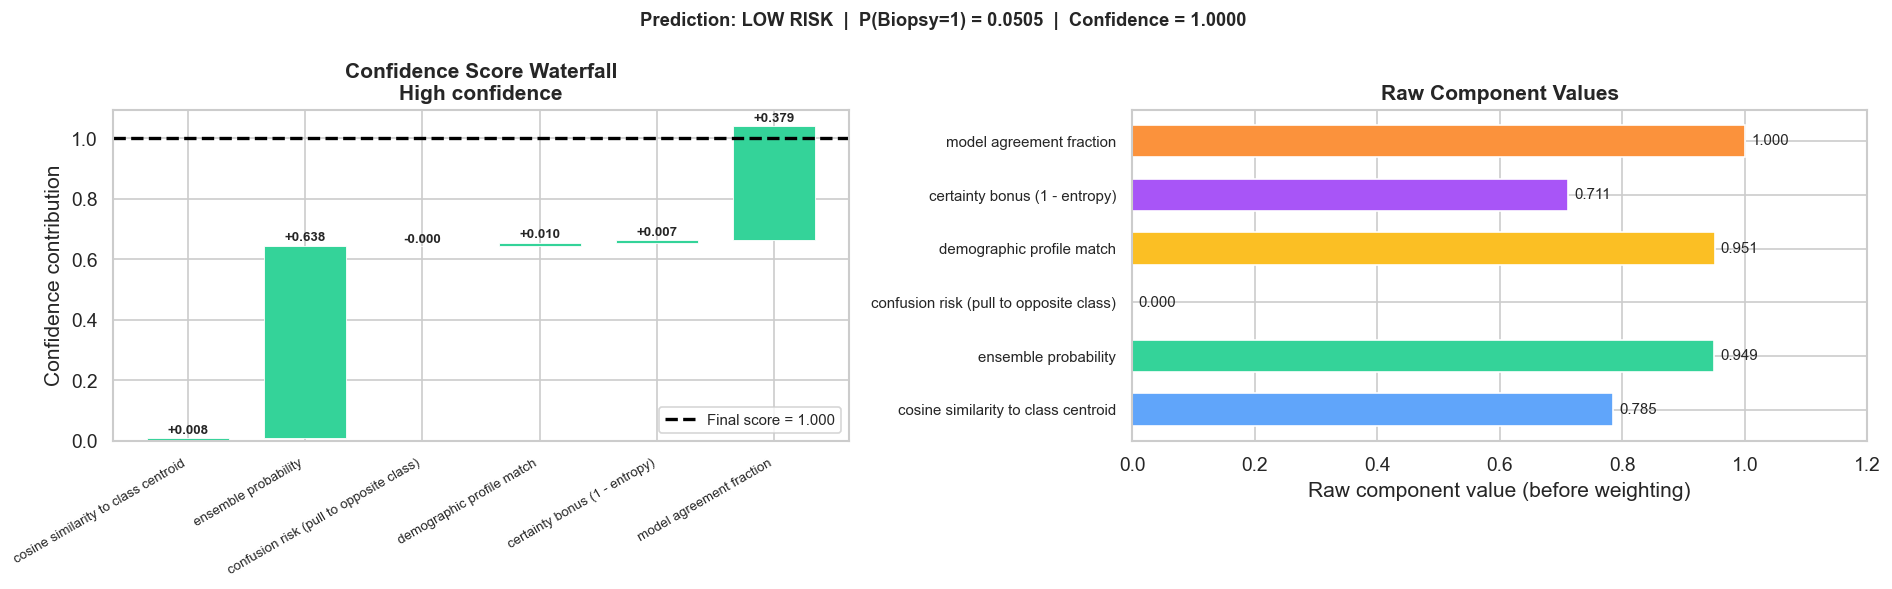

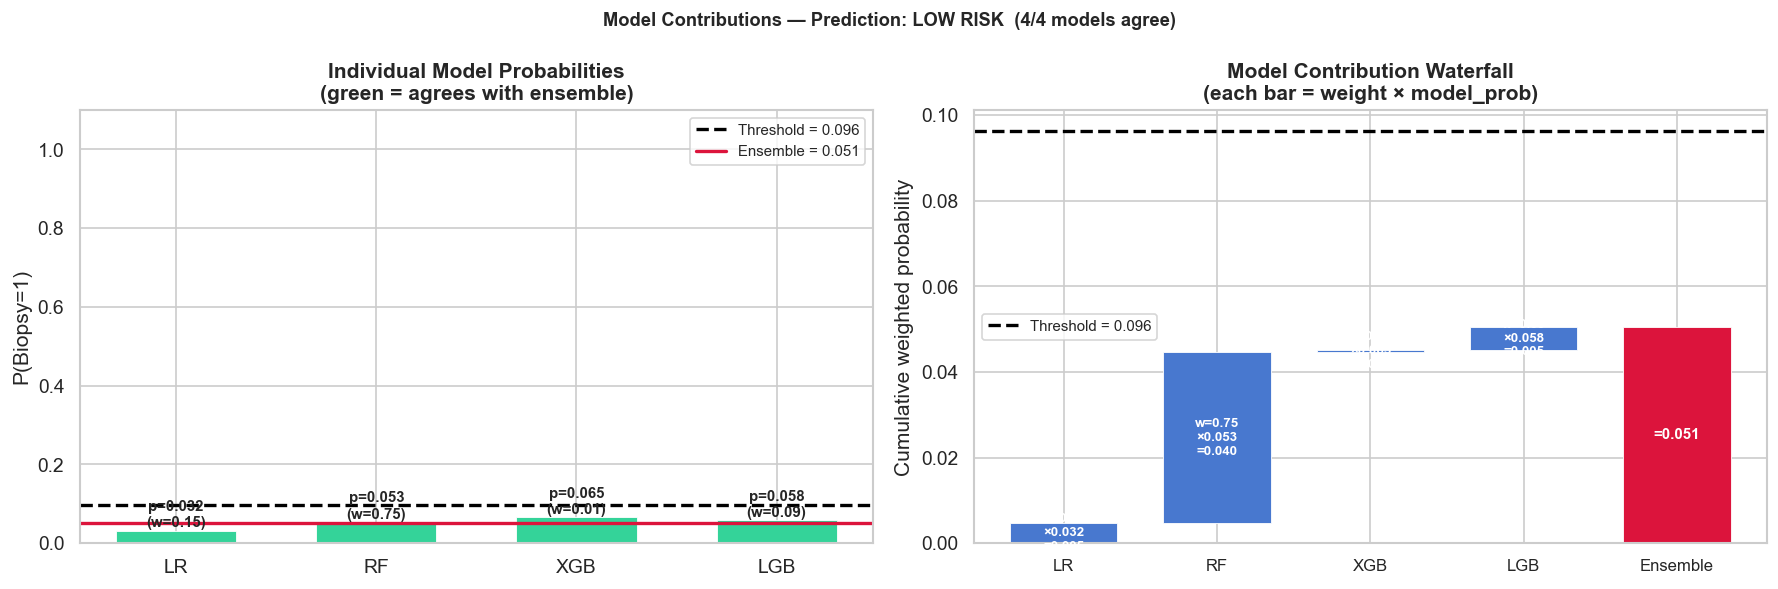

In [23]:
# Confidence waterfall plot
plot_confidence_waterfall(
    sample_row, ens_p_demo, ind_p_scalar,
    CONF_WEIGHTS, pred_cls,
    save_path=PLOTS_DIR / 'demo_confidence_waterfall.png'
)

# Model contribution waterfall
plot_model_contribution_waterfall(
    ind_p_scalar, ENSEMBLE_WEIGHTS, ens_p_demo, BEST_THRESHOLD,
    save_path=PLOTS_DIR / 'demo_model_contribution.png'
)

---
## 13. Patient Population Scatter (PCA)

PCA of all patients. Dot colour = true Biopsy label. Dot size = ensemble risk score. Cluster regions annotated. Current patient = gold star with callout.

PCA variance explained: PC1=35.1%  PC2=15.6%  Total=50.7%


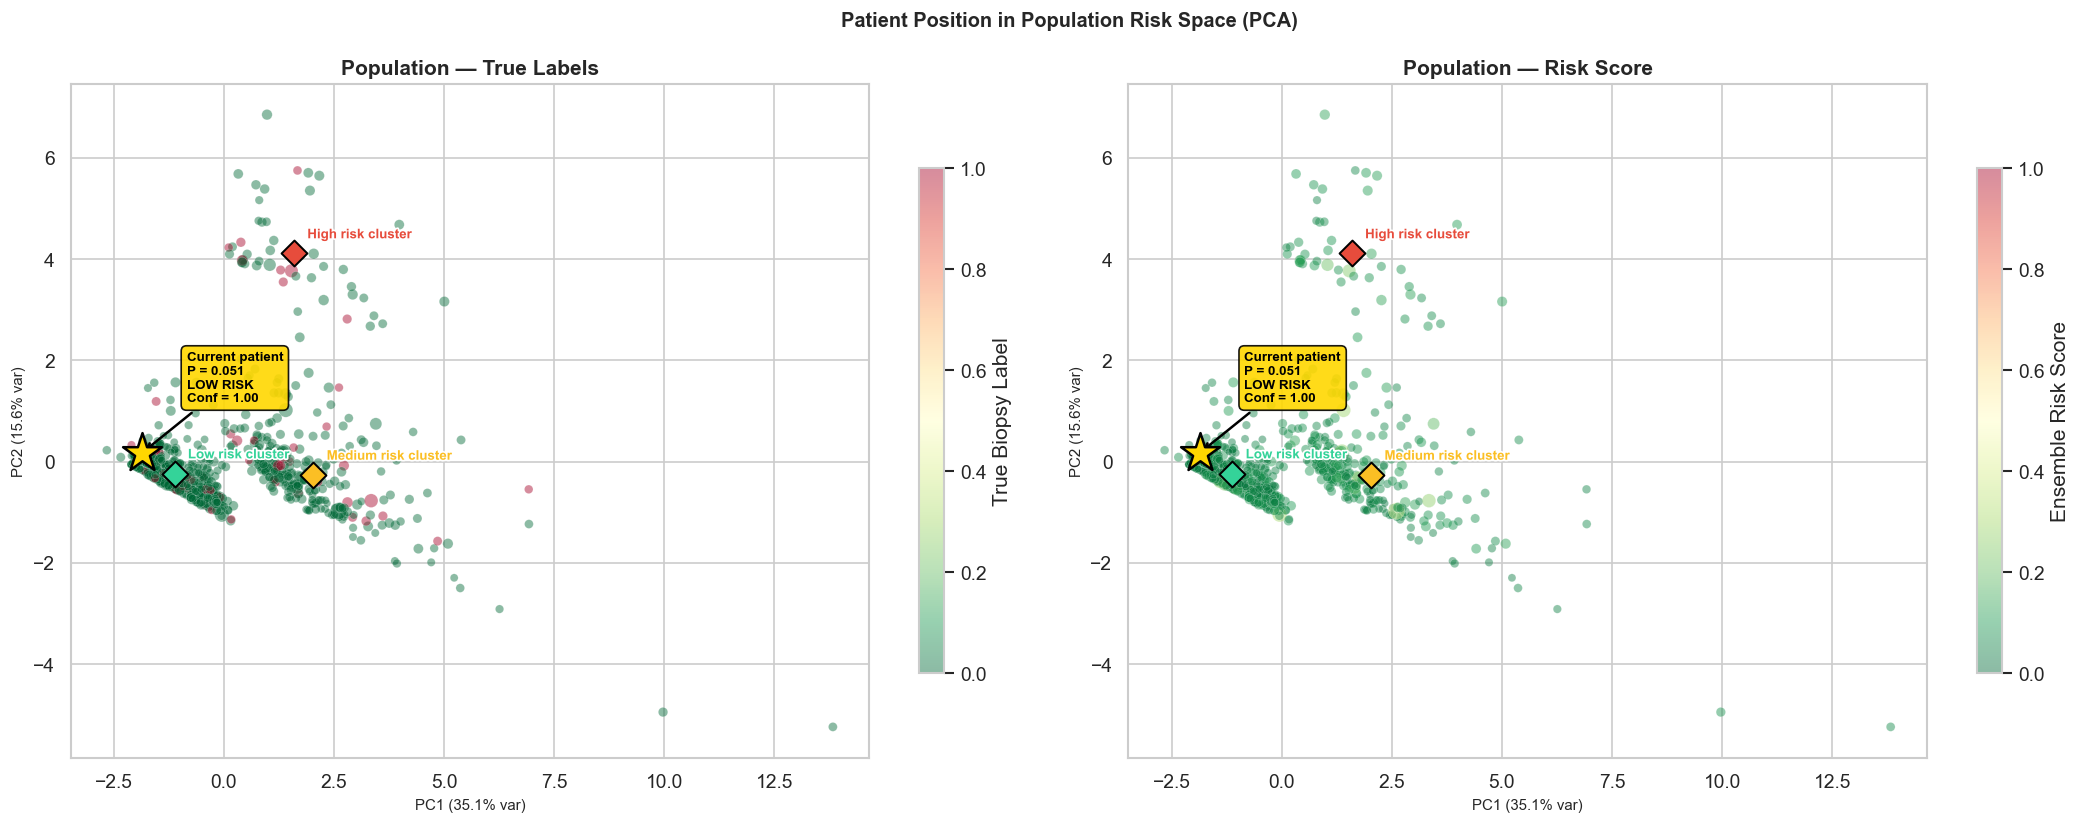

In [24]:
# Fit PCA on full dataset
pca_scaler = StandardScaler()
X_pca_all  = pca_scaler.fit_transform(X_all)
pca        = PCA(n_components=2, random_state=SEED)
X_pca_2d   = pca.fit_transform(X_pca_all)

print(f'PCA variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}  '
      f'PC2={pca.explained_variance_ratio_[1]:.1%}  '
      f'Total={sum(pca.explained_variance_ratio_):.1%}')


def plot_patient_scatter(patient_row: pd.DataFrame,
                          ens_prob_patient: float,
                          pred_class_patient: int,
                          conf_score: float,
                          all_probs: np.ndarray = full_ens_p,
                          save_path=None):
    """
    PCA scatterplot of all 858 patients.
    Left panel: coloured by true Biopsy label.
    Right panel: coloured by ensemble risk score (continuous).
    Gold star = current patient.
    """
    patient_scaled = pca_scaler.transform(patient_row)
    patient_pca    = pca.transform(patient_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, color_vals, cmap, cbar_label, title in [
        (axes[0], y_all,       'RdYlGn_r', 'True Biopsy Label',    'Population — True Labels'),
        (axes[1], all_probs,   'RdYlGn_r', 'Ensemble Risk Score',  'Population — Risk Score'),
    ]:
        # Background: all patients
        sc = ax.scatter(
            X_pca_2d[:, 0], X_pca_2d[:, 1],
            c=color_vals, cmap=cmap,
            s=np.clip(all_probs * 200 + 15, 10, 100),
            alpha=0.45, linewidths=0.2, edgecolors='white',
            vmin=0, vmax=1,
        )
        plt.colorbar(sc, ax=ax, label=cbar_label, shrink=0.75)

        # Cluster centroids with labels
        cluster_labels_map = {0:'Low risk cluster', 1:'Medium risk cluster', 2:'High risk cluster'}
        cluster_colors_map = {0:'#34d399', 1:'#fbbf24', 2:'#E74C3C'}
        for c_id in [0, 1, 2]:
            mask = (df['Cluster'] == c_id).values
            cx   = X_pca_2d[mask, 0].mean()
            cy   = X_pca_2d[mask, 1].mean()
            ax.scatter(cx, cy, marker='D', s=120,
                       color=cluster_colors_map[c_id],
                       edgecolors='black', linewidths=1.2, zorder=4)
            ax.annotate(
                cluster_labels_map[c_id],
                (cx, cy), xytext=(cx+0.3, cy+0.3),
                fontsize=8, color=cluster_colors_map[c_id], fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')],
            )

        # Current patient
        star_color = '#E74C3C' if pred_class_patient == 1 else '#34d399'
        ax.scatter(
            patient_pca[0, 0], patient_pca[0, 1],
            marker='*', s=600, c='gold', zorder=6,
            edgecolors='black', linewidths=1.5,
        )
        # Callout box
        pred_txt = 'HIGH RISK' if pred_class_patient == 1 else 'LOW RISK'
        callout  = (f'Current patient\n'
                    f'P = {ens_prob_patient:.3f}\n'
                    f'{pred_txt}\n'
                    f'Conf = {conf_score:.2f}')
        ax.annotate(
            callout,
            (patient_pca[0,0], patient_pca[0,1]),
            xytext=(patient_pca[0,0]+1.0, patient_pca[0,1]+1.0),
            fontsize=8, fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='gold',
                      alpha=0.9, edgecolor='black'),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
        )

        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=9)
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=9)
        ax.set_title(title, fontweight='bold')

    plt.suptitle('Patient Position in Population Risk Space (PCA)',
                 fontweight='bold', fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()


# Compute full dataset proba for scatter colouring
full_ens_p = np.zeros(len(X_all))
full_ens_p[list(train_idx)] = ens_oof_p
full_ens_p[list(test_idx)]  = ens_test_p

# Demo: plot the same patient from Section 12
plot_patient_scatter(
    sample_row, ens_p_demo, pred_cls, score_demo,
    all_probs=full_ens_p,
    save_path=PLOTS_DIR / 'patient_scatter.png'
)

---
## 14. Full vs No-Dx Comparison

In [25]:
print('Training RF on FULL feature set (with Dx:Cancer, Dx:HPV)...')
X_full_train = df.loc[train_idx, FEATURES_FULL].copy()
X_full_test  = df.loc[test_idx,  FEATURES_FULL].copy()

rf_full = ImbPipeline([
    ('scaler',   StandardScaler()),
    ('resample', ADASYN(random_state=SEED)),
    ('clf',      RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                         n_jobs=-1, random_state=SEED))
])
oof_full_p = cross_val_predict(rf_full, X_full_train, y_train,
                                cv=cv, method='predict_proba')[:, 1]
rf_full.fit(X_full_train, y_train)
test_full_p = rf_full.predict_proba(X_full_test)[:, 1]

comp = {
    'RF — Full (with Dx)':   {'OOF AUC': roc_auc_score(y_train, oof_full_p),
                               'Test AUC': roc_auc_score(y_test, test_full_p)},
    'Ensemble — No-Dx (v2)': {'OOF AUC': roc_auc_score(y_train, ens_oof_p),
                               'Test AUC': roc_auc_score(y_test, ens_test_p)},
}
print(pd.DataFrame(comp).T.round(4).to_string())
print('\nInsight: If No-Dx ensemble AUC is close to Full RF, Dx features are leakage, not signal.')

Training RF on FULL feature set (with Dx:Cancer, Dx:HPV)...
                       OOF AUC  Test AUC
RF — Full (with Dx)     0.6631    0.7143
Ensemble — No-Dx (v2)   0.5836    0.7685

Insight: If No-Dx ensemble AUC is close to Full RF, Dx features are leakage, not signal.


---
## 15. Save Bundle v2

In [26]:
# Final refit of all calibrated models on FULL dataset for production use
print('Refitting all models on full dataset for bundle...')
final_models = {}
for name, model in MODELS.items():
    if name == 'TabPFN':
        model.fit(X_all.values, y_all)
    else:
        cal = CalibratedClassifierCV(model, cv=3, method='isotonic')
        cal.fit(X_all, y_all)
        model = cal
    final_models[name] = model
    print(f'  {name} ✓')

# Refit centroids on full dataset
scaler_conf_full = StandardScaler()
X_conf_full_s    = scaler_conf_full.fit_transform(X_all)
centroids_full   = {
    0: X_conf_full_s[y_all==0].mean(axis=0),
    1: X_conf_full_s[y_all==1].mean(axis=0),
}
demo_pos_full = {
    'age_mean': float(X_all.loc[y_all==1, 'Age'].mean()),
    'age_std':  float(X_all.loc[y_all==1, 'Age'].std()),
}

bundle = {
    # Models
    'models':           final_models,
    'model_names':      model_names,
    'ensemble_weights': ENSEMBLE_WEIGHTS,
    # Features
    'feature_names':    FEATURES_NODX,
    'feature_names_full': FEATURES_FULL,
    # Threshold
    'threshold':        BEST_THRESHOLD,
    'target_flag_rate': TARGET_FLAG_RATE,
    # Confidence score
    'conf_weights':     CONF_WEIGHTS,
    'centroids':        centroids_full,
    'scaler_conf':      scaler_conf_full,
    'demo_pos':         demo_pos_full,
    # PCA for scatter
    'pca':              pca,
    'pca_scaler':       pca_scaler,
    'pca_coords':       X_pca_2d,
    'full_ens_proba':   full_ens_p,
    'y_all':            y_all,
    'cluster_labels':   df['Cluster'].values,
    # Cluster model
    'km_model':         km,
    'km_scaler':        scaler_cluster,
    'cluster_features': CLUSTER_FEATURES,
    # Evaluation
    'holdout_auc':      holdout_auc,
    'holdout_prauc':    holdout_prauc,
    'cv_scores':        cv_scores,
    # Confidence formula info
    'conf_formula':     'score = a*x + b*y - c*z + d*m + e*(1-H) + f*agreement',
    'conf_components':  {
        'a_cosine_sim':    round(float(CONF_WEIGHTS[0]),4),
        'b_model_proba':   round(float(CONF_WEIGHTS[1]),4),
        'c_confusion_risk':round(float(CONF_WEIGHTS[2]),4),
        'd_demographic':   round(float(CONF_WEIGHTS[3]),4),
        'e_entropy_bonus': round(float(CONF_WEIGHTS[4]),4),
        'f_agreement':     round(float(CONF_WEIGHTS[5]),4),
    },
}

joblib.dump(bundle, BUNDLE_PATH, compress=3)
print(f'\n✅  Bundle saved → {BUNDLE_PATH}')

meta = {
    'version':    'v2',
    'target':     'Biopsy',
    'features':   FEATURES_NODX,
    'models':     list(final_models.keys()),
    'tabpfn':     TABPFN_OK,
    'resampling': 'ADASYN',
    'calibration':'isotonic',
    'ensemble_weights': {n: round(float(w),4)
                         for n,w in zip(model_names, ENSEMBLE_WEIGHTS)},
    'threshold':  round(float(BEST_THRESHOLD),4),
    'flag_rate_target': TARGET_FLAG_RATE,
    'holdout_auc':  round(holdout_auc,4),
    'holdout_prauc':round(holdout_prauc,4),
    'confidence_formula': 'score = a*x + b*y - c*z + d*m + e*(1-H) + f*agreement',
    'changes_from_v1': [
        'Proper 20% stratified holdout split',
        'ADASYN replaces SMOTE',
        'TabPFN replaces SVM',
        'Per-model isotonic calibration',
        'Threshold: flag rate <=20% (was 81%)',
        'Preg_x_Age interaction feature added',
        'Confidence waterfall + model contribution waterfall',
        'Natural language explanation generator',
        'Patient population scatter (PCA)',
    ]
}
Path('cervical_model_metadata_v2.json').write_text(json.dumps(meta, indent=2))
print(f'Metadata saved → cervical_model_metadata_v2.json')
print(f'Plots saved → ./{PLOTS_DIR}/')
print(f'Total plots: {len(list(PLOTS_DIR.glob("*.png")))}')

Refitting all models on full dataset for bundle...
  LR ✓
  RF ✓
  XGB ✓
  LGB ✓

✅  Bundle saved → cervical_model_bundle_v2.joblib
Metadata saved → cervical_model_metadata_v2.json
Plots saved → ./model_plots_v2/
Total plots: 12
